## 1. Setup

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import plotly.graph_objects as go
import json
from pathlib import Path

## 2. Load and prepare football and country data

In [ ]:
country_df = pd.read_csv('your/path/to/Country_facts.csv')
country_df['Country'].unique()

<StringArray>
[             'Nigeria ',            'Guatemala ',            'Indonesia ',
                'Ghana ',           'Uzbekistan ',              'Bolivia ',
                 'Peru ',     'Papua New Guinea ',              'Tunisia ',
             'Colombia ',               'Brazil ',                'Sudan ',
             'Honduras ',              'Georgia ',            'Venezuela ',
              'Croatia ',               'Greece ',       'Czech Republic ',
               'Norway ',           'Kazakhstan ',             'Slovakia ',
             'Zimbabwe ',                'China ',            'Macedonia ',
            'Nicaragua ',                'Spain ',          'El Salvador ',
          'Netherlands ',              'Morocco ',             'Bulgaria ',
               'Angola ',        'United States ',                'Italy ',
               'Serbia ',            'Australia ',              'Romania ',
                'Chile ', 'Bosnia & Herzegovina ',     'Congo, Dem. Rep. '

In [3]:
country_df['Region'].unique()

<StringArray>
['SUB-SAHARAN AFRICA                 ',             'LATIN AMER. & CARIB    ',
       'ASIA (EX. NEAR EAST)         ',                'C.W. OF IND. STATES ',
 'OCEANIA                            ', 'NORTHERN AFRICA                    ',
 'EASTERN EUROPE                     ', 'WESTERN EUROPE                     ',
 'NORTHERN AMERICA                   ', 'NEAR EAST                          ',
                                   nan, 'BALTICS                            ']
Length: 12, dtype: str

In [ ]:
football_df = pd.read_csv('your/path/to/SoccerLEagues.csv')

# Team name fixes dictionary


fix_names = {
    "??dzki KS": "Łódzki KS",
    "??ilina": "Žilina",
    "??jpest": "Újpest",
    "??rebro": "Örebro",
    "??rgryte": "Örgryte",
    "??stanbul Ba??ak??ehir": "İstanbul Başakşehir",
    "??ster": "Öster",
    "??tvidaberg": "Åtvidaberg",
    "??ukari??ki": "Čukarički",
    "AS R??al Bamako": "AS Réal Bamako",
    "Admira Wacker M??dling": "Admira Wacker Mödling",
    "Adzop??": "Adzopé",
    "Almer??a": "Almería",
    "Am??rica": "América",
    "Ankarag??c??": "Ankaragücü",
    "Atl??tico Choloma": "Atlético Choloma",
    "Atl??tico El Vig??a": "Atlético El Vigía",
    "Atl??tico Madrid": "Atlético Madrid",
    "Atl??tico Venezuela": "Atlético Venezuela",
    "Austria K??rnten": "Austria Kärnten",
    "B??ni-Khalled": "Béni-Khalled",
    "BK H??cken": "BK Häcken",
    "BSK Bor??a": "BSK Borča",
    "Bakaridjan de Barou??li": "Bakaridjan de Barouéli",
    "Be??ikta??": "Beşiktaş",
    "Borac ??a??ak": "Borac Čačak",
    "CAS de S??var??": "CAS de Sévaré",
    "Caron??": "Caroní",
    "Central Espa??ol": "Central Español",
    "Centre Salif K??ita": "Centre Salif Kéita",
    "Centro ??talo": "Centro Ítalo",
    "Dengu??l?? Sport": "Denguélé Sport",
    "Deportivo Anzo??tegui": "Deportivo Anzoátegui",
    "Deportivo La Coru??a": "Deportivo La Coruña",
    "Deportivo T??chira": "Deportivo Táchira",
    "Di??sgy??r": "Diósgyőr",
    "Djurg??rden": "Djurgården",
    "Dom??ale": "Domžale",
    "Elaz????spor": "Elazığspor",
    "Eski??ehirspor": "Eskişehirspor",
    "Estudiantes de M??rida": "Estudiantes de Mérida",
    "F??nix": "Fénix",
    "FK Liep??jas Metalurgs": "FK Liepājas Metalurgs",
    "FK Mladost Lu??ani": "FK Mladost Lučani",
    "Feh??rv??r": "Fehérvár",
    "Fenerbah??e": "Fenerbahçe",
    "Ferencv??ros": "Ferencváros",
    "Gab??s": "Gabès",
    "Gen??lerbirligi": "Gençlerbirliği",
    "Grasshopper Club Z??rich": "Grasshopper Club Zürich",
    "Gy??ri ETO": "Győri ETO",
    "H??rcules": "Hércules",
    "Honv??d": "Honvéd",
    "IFK G??teborg": "IFK Göteborg",
    "In??ija": "Inđija",
    "J??bilo Iwata": "Júbilo Iwata",
    "Kaposv??ri R??k??czi": "Kaposvári Rákóczi",
    "Karab??kspor": "Karabükspor",
    "Kas??mpa??a": "Kasımpaşa",
    "Kecskem??ti TE": "Kecskeméti TE",
    "Ko??ice": "Košice",
    "Le??n": "León",
    "M??laga": "Málaga",
    "Malm?? FF": "Malmö FF",
    "Marath??n": "Marathón",
    "Mersin ??dmanyurdu": "Mersin İdmanyurdu",
    "Mez??k??vesd-Zs??ry": "Mezőkövesd-Zsóry",
    "Mictl??n": "Mictlán",
    "Mj??llby": "Mjällby",
    "Neuch??tel Xamax": "Neuchâtel Xamax",
    "Norrk??ping": "Norrköping",
    "Ny??regyh??za Spartacus": "Nyíregyháza Spartacus",
    "Olympique B??ja": "Olympique Béja",
    "Onze Cr??ateurs": "Onze Créateurs",
    "Osmanl??spor FK": "Osmanlıspor FK",
    "P??bram": "Příbram",
    "P??csi MFC": "Pécsi MFC",
    "P??pa": "Pápa",
    "Pe??arol": "Peñarol",
    "Petr??alka": "Petržalka",
    "Pusk??s FC": "Puskás FC",
    "Quer??taro": "Querétaro",
    "Rabotni??ki": "Rabotnički",
    "Radni??ki  Kragujevac": "Radnički Kragujevac",
    "Radni??ki Ni??": "Radnički Niš",
    "Real Espa??a": "Real España",
    "Ru??omberok": "Ružomberok",
    "S??w??": "Séwé",
    "SO Arm??e": "SO Armée",
    "Sab??": "Sabé",
    "Sf??ntul Gheorghe": "Sfântul Gheorghe",
    "Si??fok": "Siófok",
    "Sloboda U??ice": "Sloboda Užice",
    "Speran??a Crihana": "Speranța Crihana",
    "Sporting Gij??n": "Sporting Gijón",
    "Stade Gab??sien": "Stade Gabésien",
    "Suchitep??quez": "Suchitepéquez",
    "Sud Am??rica": "Sud América",
    "Szolnoki M??V": "Szolnoki MÁV",
    "Szombathelyi Halad??s": "Szombathelyi Haladás",
    "Tacuaremb??": "Tacuarembó",
    "Tatran Pre??ov": "Tatran Prešov",
    "Tren????n": "Trenčín",
    "Vo??dovac": "Voždovac",
    "Widzew ??dz": "Widzew Łódź",
    "Xelaj??": "Xelajú",
    "Z??rich": "Zürich",
    "Zag??bie Lubin": "Zagłębie Lubin",
    "Zaria B??l??i": "Zaria Bălți",
    "Zavr??": "Zavrč"
}

# Apply fixes

football_df["Team"] = football_df["Team"].replace(fix_names)


football_df['Team'].unique()

<StringArray>
[       'MC Oran', 'NA Hussein Dey',    'MC El Eulma',         'Annaba',
         'Khroub',          'Sa?da',    'A?n Fakroun',      'USM Blida',
       'ASM Oran',       'RC Arba?',
 ...
    'CAPS United',        'Dynamos', 'Njube Sundowns',    'Chiredzi FC',
    'Highlanders',     'ZPC Kariba',       'Hardbody',         'Eagles',
          'Dongo',     'Tsholotsho']
Length: 1975, dtype: str

In [5]:
football_df.head()

,Sport,Country,League,Year,Season,Team,Games,HomeWins,HomeDraw,HomeLoss,HomeRatio,AwayWins,AwayDraw,AwayLoss,AwayGoalsDiff,Unnamed: 15
0,Football,Algeria,Algeria-Ligue-1,2010,-,MC Oran,34,10,5,2,11,0,6,11,-20,NaN
1,Football,Algeria,Algeria-Ligue-1,2010,-,NA Hussein Dey,34,3,5,9,-8,0,5,12,-19,NaN
2,Football,Algeria,Algeria-Ligue-1,2011,-,MC El Eulma,29,9,3,2,13,0,6,9,-19,NaN
3,Football,Algeria,Algeria-Ligue-1,2011,-,Annaba,29,10,5,0,14,0,1,13,-23,NaN
4,Football,Algeria,Algeria-Ligue-1,2012,-,Khroub,30,7,5,3,0,0,5,10,-23,NaN


In [6]:
football_df['League'].unique()

<StringArray>
[                        'Algeria-Ligue-1',
                         'Angola-Girabola',
                       'Argentina-Primera',
                      'Australia-A-League',
                      'Austria-Bundesliga',
               'Azerbaijan-Premier-League',
                         'Belarus-Premier',
                  'Belgium-Jupiler-League',
                'Bolivia-Primera-Division',
    'Bosnia-and-Herzegovina-Premijer-Liga',
                          'Brazil-Serie-A',
                          'Bulgaria-A-PFG',
                      'Cameroon-Elite-One',
                           'Chile-Primera',
                   'China-PR-Super-League',
                'Colombia-Liga-Postobon-I',
                       'Congo-DR-Linafoot',
                       'Croatia-1.-League',
               'Cyprus-1st-League-Phase-A',
           'Czech-Republic-Gambrinus-liga',
                     'Denmark-Superligaen',
                         'Ecuador-Serie-A',
                  

In [7]:
country_df['Country'] = country_df['Country'].str.strip()
football_df['Country'] = football_df['Country'].str.strip()

df_merged = pd.merge(country_df, football_df, on='Country', how='inner')

# Main df for plots: drop countries with missing values in key columns
df_merged = df_merged.dropna(subset=['Region', 'GDP', 'Literacy'])

In [8]:
df_merged.head()

,Country,Region,Population,Area,PopDensity,Coastline,Net migration,Infant_mortality,GDP,Literacy,...,Games,HomeWins,HomeDraw,HomeLoss,HomeRatio,AwayWins,AwayDraw,AwayLoss,AwayGoalsDiff,Unnamed: 15
0,Nigeria,SUB-SAHARAN AFRICA,131859731,923768,142.7,0.09,0.26,98.8,900.0,68.0,...,38,17,1,1,30,0,6,13,-23,NaN
1,Nigeria,SUB-SAHARAN AFRICA,131859731,923768,142.7,0.09,0.26,98.8,900.0,68.0,...,38,16,2,1,24,0,4,15,-20,NaN
2,Nigeria,SUB-SAHARAN AFRICA,131859731,923768,142.7,0.09,0.26,98.8,900.0,68.0,...,38,16,2,1,24,0,2,17,-23,NaN
3,Nigeria,SUB-SAHARAN AFRICA,131859731,923768,142.7,0.09,0.26,98.8,900.0,68.0,...,38,13,6,0,19,0,6,13,-19,NaN
4,Nigeria,SUB-SAHARAN AFRICA,131859731,923768,142.7,0.09,0.26,98.8,900.0,68.0,...,38,13,4,2,23,0,4,15,-21,NaN


## 3. Team-level home advantage metrics

In [9]:
df_merged = df_merged.drop(columns=['Unnamed: 15'], errors='ignore')
team_summary = (
    df_merged.groupby(['Country', 'League', 'Team'], as_index=False)
      .agg(
          seasons_played=('Year', 'nunique'),
          first_year=('Year', 'min'),
          last_year=('Year', 'max'),
          total_games=('Games', 'sum'),
          avg_games=('Games', 'mean'),
          total_home_wins=('HomeWins', 'sum'),
          total_home_draws=('HomeDraw', 'sum'),
          total_home_losses=('HomeLoss', 'sum'),
          avg_home_ratio=('HomeRatio', 'mean'),
          total_away_wins=('AwayWins', 'sum'),
          total_away_draws=('AwayDraw', 'sum'),
          total_away_losses=('AwayLoss', 'sum'),
          total_away_goals_diff=('AwayGoalsDiff', 'sum'),

          # country-level features
          region=('Region', 'first'),
          gdp=('GDP', 'first'),
          agriculture=('Agriculture', 'first'),
          industry=('Industry', 'first'),
          service=('Service', 'first'),
          net_migration=('Net migration', 'first'),
          literacy=('Literacy', 'first')
      )
)

team_summary.head()

,Country,League,Team,seasons_played,first_year,last_year,total_games,avg_games,total_home_wins,total_home_draws,...,total_away_draws,total_away_losses,total_away_goals_diff,region,gdp,agriculture,industry,service,net_migration,literacy
0,Angola,Angola-Girabola,? de Agosto,8,2009,2016,199,24.875,64,19,...,35,24,33,SUB-SAHARAN AFRICA,1900.0,0.096,0.658,0.246,0.0,42.0
1,Angola,Angola-Girabola,? de Maio,5,2009,2016,111,22.200,17,15,...,16,31,-46,SUB-SAHARAN AFRICA,1900.0,0.096,0.658,0.246,0.0,42.0
2,Angola,Angola-Girabola,ASA Luanda,8,2009,2016,197,24.625,38,28,...,27,45,-39,SUB-SAHARAN AFRICA,1900.0,0.096,0.658,0.246,0.0,42.0
3,Angola,Angola-Girabola,Acad?mica Lobito,4,2009,2016,85,21.250,14,12,...,3,36,-59,SUB-SAHARAN AFRICA,1900.0,0.096,0.658,0.246,0.0,42.0
4,Angola,Angola-Girabola,Acad?mica do Soyo,4,2009,2012,108,27.000,23,13,...,12,28,-20,SUB-SAHARAN AFRICA,1900.0,0.096,0.658,0.246,0.0,42.0


In [10]:
team_summary['Team'].unique()

<StringArray>
[       '? de Agosto',          '? de Maio',         'ASA Luanda',
   'Acad?mica Lobito',  'Acad?mica do Soyo', 'Atl?tico do Namibe',
     'Benfica Luanda',            'Cabinda',   'Desportivo Hu?la',
          'Domant FC',
 ...
           'Quelaton',      'Shabanie Mine',        'Triangle FC',
          'Tripple B',         'Tsholotsho',          'Underhill',
        'WWS Rangers',             'WhaWha',         'ZPC Kariba',
    'Zimbabwe Saints']
Length: 1590, dtype: str

## Main metric to compute home advantage: Home-away point difference

In [11]:
team_summary['home_points'] = (
    3 * team_summary['total_home_wins'] +
    1 * team_summary['total_home_draws']
)

team_summary['away_points'] = (
    3 * team_summary['total_away_wins'] +
    1 * team_summary['total_away_draws']
)

team_summary['points_diff'] = (
    team_summary['home_points'] - team_summary['away_points']
)

In [12]:
team_summary['points_diff_per_game'] = team_summary['points_diff'] / team_summary['total_games']
team_summary['region'] = team_summary['region'].str.strip()
team_summary['region'].unique()

<StringArray>
[  'SUB-SAHARAN AFRICA',  'LATIN AMER. & CARIB',              'OCEANIA',
       'WESTERN EUROPE',  'C.W. OF IND. STATES',       'EASTERN EUROPE',
 'ASIA (EX. NEAR EAST)',            'NEAR EAST',      'NORTHERN AFRICA',
              'BALTICS']
Length: 10, dtype: str

In [45]:
fig = px.histogram(
    team_summary, 
    x='points_diff_per_game', 
    nbins=50,
    title='Distribution of Points Difference Per Game by Team',
    labels={'points_diff_per_game': 'Points Difference Per Game'},
    #marginal='box', # Adds a box plot above to help visualize the spread and outliers
    opacity=0.8,
    color_discrete_sequence=['#1f77b4']
)

# Add a red dashed line at 0 to show the baseline of "No Advantage"
fig.add_vline(x=0, line_dash="dash", line_color="red", annotation_text="No Advantage (0 diff)")

fig.update_layout(yaxis_title='Number of Teams')
fig.show()

This plot is the main confirmation of home advantage being a real thing, and our main motivation to try to explain it.

In [13]:

# 1. Define the custom order of your regions to group nearby locations
custom_region_order = [
    "WESTERN EUROPE", "EASTERN EUROPE", "BALTICS", "C.W. OF IND. STATES",  # Europe grouping
    "NEAR EAST", "ASIA (EX. NEAR EAST)",     # Asia grouping
    'NORTHERN AFRICA', 'SUB-SAHARAN AFRICA',
    "LATIN AMER. & CARIB", # Americas grouping
    'OCEANIA'
    # ... add all other regions from your dataset in the exact order you want
]

# 2. Define a color map to assign the same color to clustered regions
region_colors = {
    # Europe - Blue
    "WESTERN EUROPE": "#1f77b4",  
    "EASTERN EUROPE": "#1f77b4",  
    "BALTICS": "#1f77b4",
    "C.W. OF IND. STATES": "#1f77b4",         
    
    # Americas - Green
    "LATIN AMER. & CARIB": "#0D6629", 
    
    # Asia - Orange
    "NEAR EAST": "#d7b300",       
    "ASIA (EX. NEAR EAST)": "#d7b300", 


    'NORTHERN AFRICA': "#7e4517",      
    'SUB-SAHARAN AFRICA': "#7e4517",

    'OCEANIA': "#820EFF"
    # ... ensure every region in your dataset has a color mapped to it
} 


# Create the base violin plot with swapped axes
fig = px.violin(
    team_summary,
    x="points_diff_per_game",  # Swapped: Numerical data is now on the x-axis
    y="region",             # Swapped: Categorical data is now on the y-axis
    color="region",         # Coloring by region helps visually separate the overlapping ridges
    #points="all",           # Displays each team as a dot under the ridge
    #hover_data=["Team"],    # Shows the team name when hovering over a dot
    title="Regional Distribution of Points Difference Per Game",
    
    category_orders={"region": custom_region_order},  # Forces the custom sorting
    color_discrete_map=region_colors
)

# Add the specific vertical line at x=0
fig.add_vline(x=0, line_width=1, line_color='#000000', opacity=0.5, line_dash='dash')

# Update traces to transform the violins into a ridge plot
fig.update_traces(
    orientation='h',        # Ensure the plot is drawn horizontally
    side='positive',        # Cuts the violin in half, leaving only the top "ridge"
    width=2.5,              # Increases the width so the distributions overlap vertically
    #marker_opacity=0.6     # Lowers the opacity of the dots so they don't visually overwhelm the plot
    #line_color="black" 
    hoveron=None      
)

# Apply axis styling (X solid with trims/ticks, Y hidden line/ticks)
fig.update_xaxes(
    showline=True, 
    linecolor='black', 
    linewidth=.5,
    ticks='outside',

    showgrid=True,
    gridcolor='HSL(0, 0%, 80%)', # Light gray grid lines for better readability

    title_font=dict(size=12),
    title_text='Points Difference Between Home and Away Games',
    range=[-0.75, 1.5],
    anchor='free',
    #shift=10
)
fig.update_yaxes(
    showline=False, 
    anchor='free',
    shift=-10,
    ticks=''
)

# Customize the layout for a clean, readable appearance
fig.update_layout(
    width=720,
    height=480,
    font=dict(family='Roboto'),
    plot_bgcolor='#f7f4ef',
    paper_bgcolor='#f7f4ef',
    
    title_x=0.5,        # Centers the title horizontally
    title_y=0.95,       # Moves the title slightly down from the top edge
    title_font_size=18,

    yaxis_title=None,  # Y-axis title is unnecessary since the regions are already labeled
    
    showlegend=False,       # The y-axis already labels the regions, so a legend is redundant

    margin=dict(
        l=160,  # Left margin in pixels
        #r=0,  # Right margin in pixels
        t=64,  # Top margin (often set slightly larger to accommodate the title)
        #b=100   # Bottom margin in pixels
    )
)

# Display the plot
fig.write_image('Regional_Distribution_of_Points_Difference_Per_Game.png')
fig.show()


## 4. Country and region summaries

In [14]:
country_summary = (
    team_summary.groupby('Country', as_index=False)
    .agg(
        n_teams=('Team', 'nunique'),
        total_seasons=('seasons_played', 'sum'),

        total_games=('total_games', 'sum'),

        total_home_points=('home_points', 'sum'),
        total_away_points=('away_points', 'sum'),
        points_diff=('points_diff', 'sum'),
        
        total_goal_diff=('total_away_goals_diff', 'sum'),

        avg_home_ratio=('avg_home_ratio', 'mean'),

        # keep country features (same for all teams)
        region=('region', 'first'),
        gdp=('gdp', 'first'),
        agriculture=('agriculture', 'first'),
        industry=('industry', 'first'),
        service=('service', 'first'),
        net_migration=('net_migration', 'first'),
        literacy=('literacy', 'first')
    )
)

country_summary.head()

,Country,n_teams,total_seasons,total_games,total_home_points,total_away_points,points_diff,total_goal_diff,avg_home_ratio,region,gdp,agriculture,industry,service,net_migration,literacy
0,Angola,26,126,3146,2565,1692,873,-548,2.527564,SUB-SAHARAN AFRICA,1900.0,0.096,0.658,0.246,0.00,42.0
1,Argentina,27,109,2070,1570,1167,403,-327,2.084568,LATIN AMER. & CARIB,11200.0,0.095,0.358,0.547,0.61,97.1
2,Australia,12,61,1640,1388,872,516,-348,5.175000,OCEANIA,29000.0,0.038,0.262,0.700,3.98,100.0
3,Austria,17,63,3506,2821,1957,864,-716,2.475724,WESTERN EUROPE,30000.0,0.018,0.304,0.678,2.00,98.0
4,Azerbaijan,17,68,1586,1268,1088,180,-300,3.090196,C.W. OF IND. STATES,3400.0,0.141,0.457,0.402,-4.90,97.0


In [15]:
country_summary['points_diff_per_game'] = (
    (country_summary['total_home_points'] - country_summary['total_away_points']) 
    / country_summary['total_games']
)
country_summary['away_goal_diff_per_game'] = (
    country_summary['total_goal_diff'] / country_summary['total_games']
)

## GDP Analysis

C:\Users\nicos\AppData\Local\Temp\ipykernel_27212\1531571389.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_plot['Country'], rotation=90)


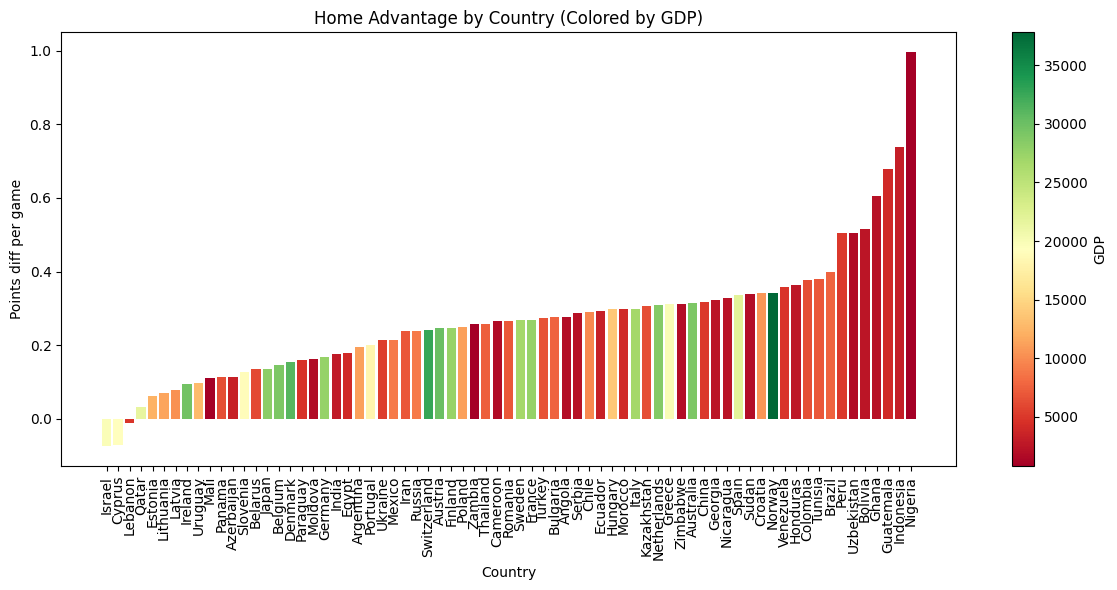

In [19]:
df_plot = country_summary.sort_values('points_diff_per_game')

fig, ax = plt.subplots(figsize=(12, 6))

# Normalize GDP
norm = mcolors.Normalize(vmin=df_plot['gdp'].min(), vmax=df_plot['gdp'].max())
cmap = cm.RdYlGn

colors = cmap(norm(df_plot['gdp']))

# Plot
ax.bar(df_plot['Country'], df_plot['points_diff_per_game'], color=colors)

ax.set_xticklabels(df_plot['Country'], rotation=90)
ax.set_xlabel('Country')
ax.set_ylabel('Points diff per game')
ax.set_title('Home Advantage by Country (Colored by GDP)')

# Colorbar FIX
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='GDP')  # 👈 key fix

plt.tight_layout()
plt.show()

C:\Users\nicos\AppData\Local\Temp\ipykernel_27212\3010566165.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_plot['Country'], rotation=90)


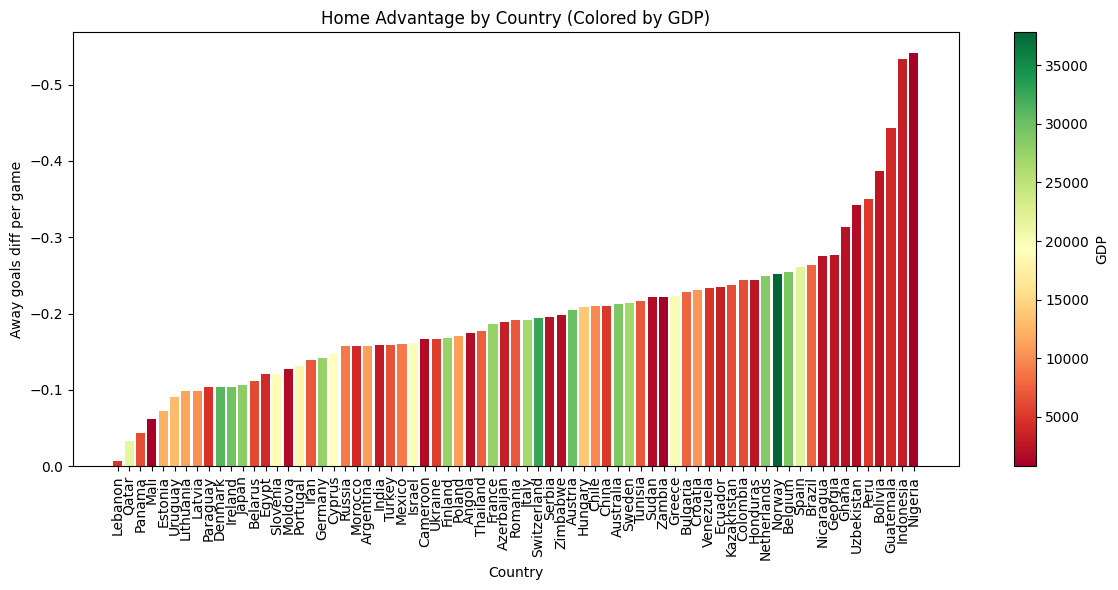

In [23]:
df_plot = country_summary.sort_values('away_goal_diff_per_game')

fig, ax = plt.subplots(figsize=(12, 6))

# Normalize GDP
norm = mcolors.Normalize(vmin=df_plot['gdp'].min(), vmax=df_plot['gdp'].max())
cmap = cm.RdYlGn

colors = cmap(norm(df_plot['gdp']))

# Plot
ax.bar(df_plot['Country'], df_plot['away_goal_diff_per_game'], color=colors)

ax.set_xticklabels(df_plot['Country'], rotation=90)
ax.set_xlabel('Country')
ax.set_ylabel('Away goals diff per game')
ax.set_title('Home Advantage by Country (Colored by GDP)')
ax.invert_yaxis()
ax.invert_xaxis()
# Colorbar FIX
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='GDP')  

plt.tight_layout()
plt.show()

## Literacy analysis

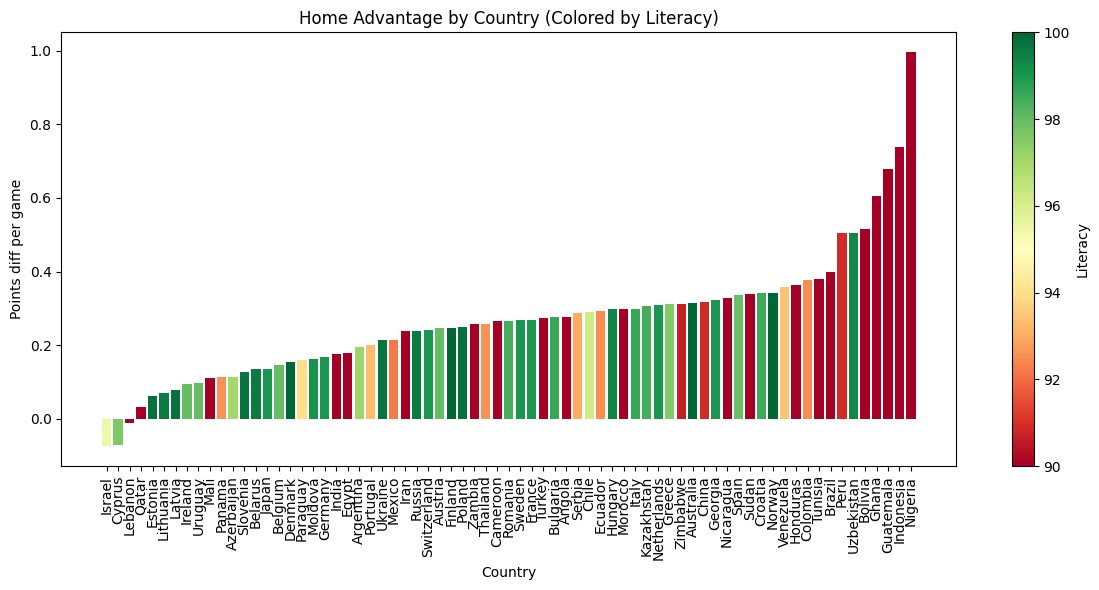

In [25]:
df_plot = country_summary.sort_values('points_diff_per_game')

fig, ax = plt.subplots(figsize=(12, 6))

min_lit = 90
lit_clipped = np.clip(df_plot['literacy'], min_lit, df_plot['literacy'].max())
norm = mcolors.Normalize(
    vmin=min_lit,
    vmax=df_plot['literacy'].max(),
    clip=True
)

colors = cmap(norm(df_plot['literacy']))
colors = cmap(norm(lit_clipped))

# Plot
ax.bar(df_plot['Country'], df_plot['points_diff_per_game'], color=colors)

ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot['Country'], rotation=90)
ax.set_xlabel('Country')
ax.set_ylabel('Points diff per game')
ax.set_title('Home Advantage by Country (Colored by Literacy)')

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Literacy')

plt.tight_layout()
plt.show()

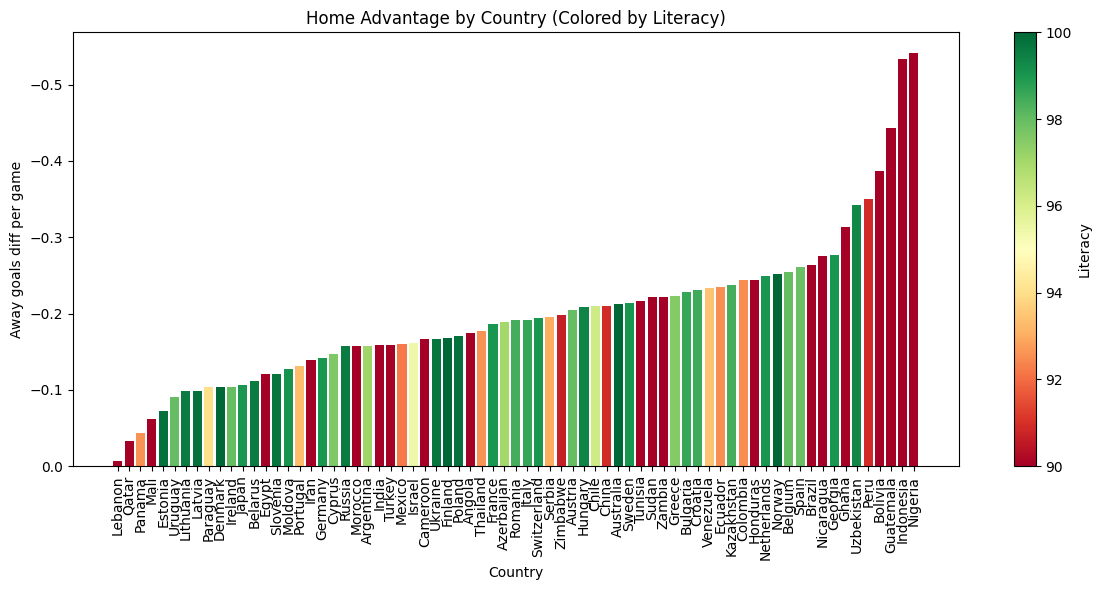

In [26]:
df_plot = country_summary.sort_values('away_goal_diff_per_game')
fig, ax = plt.subplots(figsize=(12, 6))

min_lit = 90
lit_clipped = np.clip(df_plot['literacy'], min_lit, df_plot['literacy'].max())
norm = mcolors.Normalize(
    vmin=min_lit,
    vmax=df_plot['literacy'].max(),
    clip=True
)

colors = cmap(norm(df_plot['literacy']))
colors = cmap(norm(lit_clipped))

# Plot
ax.bar(df_plot['Country'], df_plot['away_goal_diff_per_game'], color=colors)

ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot['Country'], rotation=90)
ax.set_xlabel('Country')
ax.set_ylabel('Away goals diff per game')
ax.set_title('Home Advantage by Country (Colored by Literacy)')
ax.invert_yaxis()
ax.invert_xaxis()
# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Literacy')

plt.tight_layout()
plt.show()

In [27]:
region_summary = (
    country_summary.groupby('region', as_index=False)
    .agg(
        n_countries=('Country', 'nunique'),
        total_seasons=('total_seasons', 'sum'),
        total_games=('total_games', 'sum'),
        total_home_points=('total_home_points', 'sum'),
        total_away_points=('total_away_points', 'sum'),
        points_diff=('points_diff', 'sum'),
        points_diff_per_game=('points_diff_per_game', 'mean'),
        total_goal_diff=('total_goal_diff', 'sum'),
        avg_home_ratio=('avg_home_ratio', 'mean'),
        avg_gdp=('gdp', 'mean'),
        avg_literacy=('literacy', 'mean')
    )
)


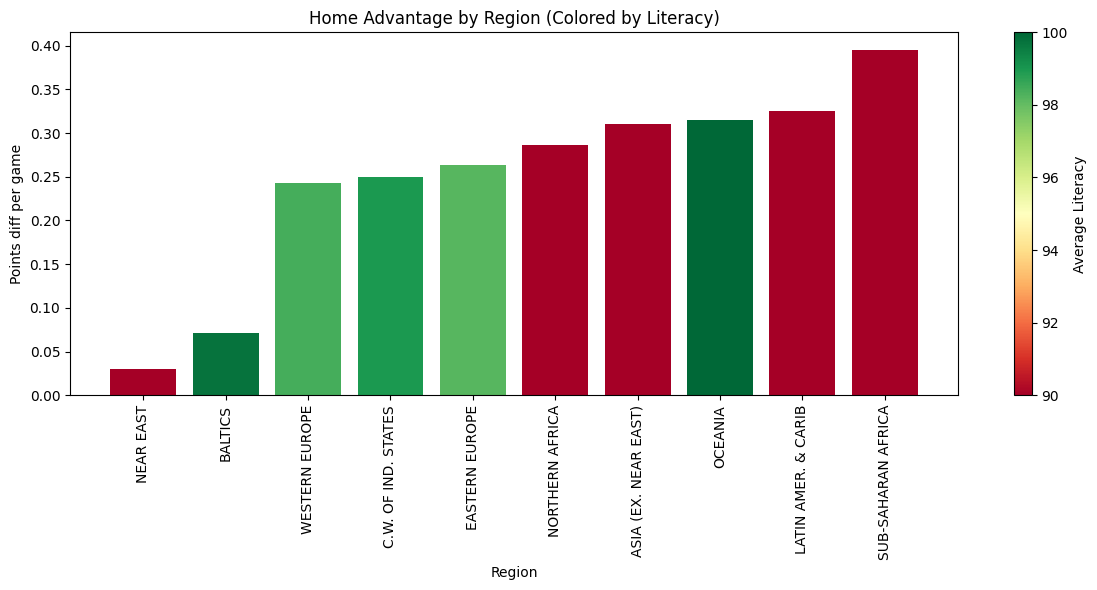

In [29]:
df_plot = region_summary.sort_values('points_diff_per_game')

min_lit = 90
lit_clipped = np.clip(df_plot['avg_literacy'], min_lit, df_plot['avg_literacy'].max())
norm = mcolors.Normalize(
    vmin=min_lit,
    vmax=df_plot['avg_literacy'].max(),
    clip=True
)

fig,ax = plt.subplots(figsize=(12, 6))

cmap = cm.RdYlGn
colors = cmap(norm(df_plot['avg_literacy']))
ax.bar(df_plot['region'], df_plot['points_diff_per_game'], color=colors)
ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot['region'], rotation=90)
ax.set_xlabel('Region')
ax.set_ylabel('Points diff per game')
ax.set_title('Home Advantage by Region (Colored by Literacy)')
# Colorbar FIX
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Average Literacy')
plt.tight_layout()
plt.show()

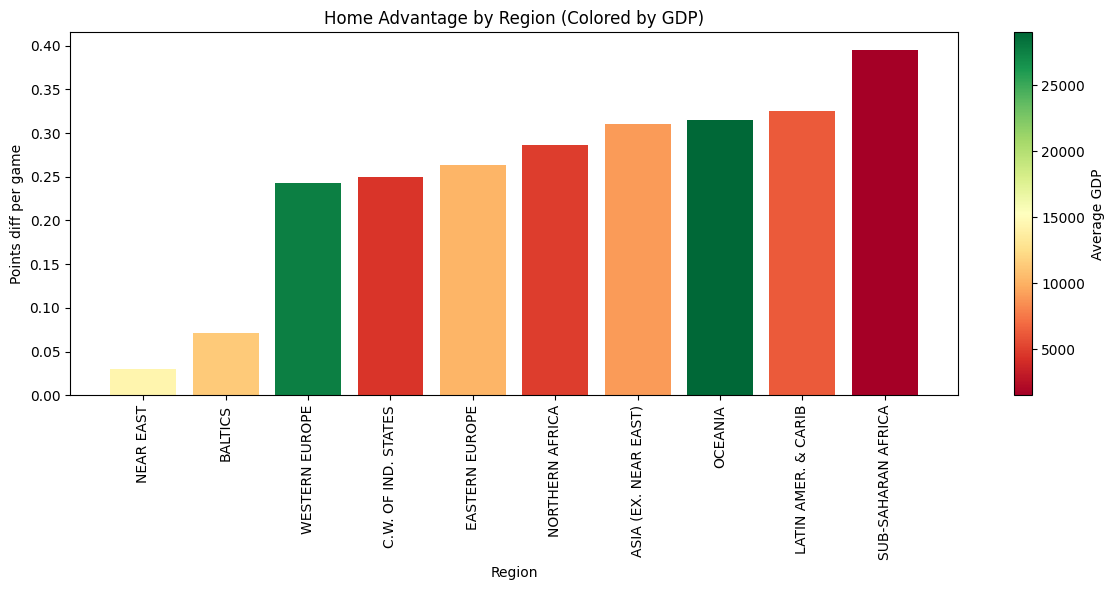

In [30]:
df_plot = region_summary.sort_values('points_diff_per_game')

fig,ax = plt.subplots(figsize=(12, 6))
norm = mcolors.Normalize(vmin=df_plot['avg_gdp'].min(), vmax=df_plot['avg_gdp'].max())
cmap = cm.RdYlGn
colors = cmap(norm(df_plot['avg_gdp']))
ax.bar(df_plot['region'], df_plot['points_diff_per_game'], color=colors)
ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot['region'], rotation=90)
ax.set_xlabel('Region')
ax.set_ylabel('Points diff per game')
ax.set_title('Home Advantage by Region (Colored by GDP)')
# Colorbar FIX
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Average GDP')
plt.tight_layout()
plt.show()

All region and country wise plots colored show patterns that motivate further studies about the influence of socioeconomic factors to home advantage.

## 5. Map data and interactive football visualizations

## Here we use all the countries available for a more complete map

In [41]:
df_merged_map = pd.merge(
    country_df,
    football_df,
    on='Country',
    how='outer'
)

df_merged_map['Country'] = df_merged_map['Country'].str.strip()

df_merged_map['home_points'] = (
    3 * df_merged_map['HomeWins'] + df_merged_map['HomeDraw']
)

df_merged_map['away_points'] = (
    3 * df_merged_map['AwayWins'] + df_merged_map['AwayDraw']
)

df_merged_map['points_diff'] = (
    df_merged_map['home_points'] - df_merged_map['away_points']
)

df_merged_map['total_games'] = (
    df_merged_map['HomeWins'] + df_merged_map['HomeDraw'] + df_merged_map['HomeLoss'] +
    df_merged_map['AwayWins'] + df_merged_map['AwayDraw'] + df_merged_map['AwayLoss']
)

map_df = (
    df_merged_map.groupby('Country', as_index=False)
    .agg(
        total_home_points=('home_points', 'sum'),
        total_away_points=('away_points', 'sum'),
        total_games=('total_games', 'sum')
    )
)

map_df['points_diff'] = map_df['total_home_points'] - map_df['total_away_points']

map_df['points_diff_per_game'] = np.where(
    map_df['total_games'] > 0,
    map_df['points_diff'] / map_df['total_games'],
    np.nan
)

map_df = map_df.dropna(subset=['points_diff_per_game'])

max_abs = map_df['points_diff_per_game'].abs().max()

map_df = map_df.dropna(subset=['points_diff_per_game'])
country_fix = {
    'England': 'United Kingdom',
    'Scotland': 'United Kingdom',
    'Wales': 'United Kingdom',
    'Northern Ireland': 'United Kingdom',
    
    'USA': 'United States',
    'US': 'United States',
    'United States of America': 'United States',
    
    'Czech Republic': 'Czechia',
    'Ivory': "Côte d'Ivoire",
    'Bosnia': 'Bosnia and Herzegovina'
}

map_df['Country_map'] = map_df['Country'].replace(country_fix)

fig = px.choropleth(
    map_df,
    locations='Country_map',
    locationmode='country names',
    color='points_diff_per_game',
    hover_name='Country',
    hover_data={'points_diff_per_game': ':.3f'},
    color_continuous_scale='RdYlGn_r',
    range_color=[-max_abs, max_abs],
    title='Home vs Away Points Difference per Game by Country'
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    margin=dict(l=0, r=0, t=50, b=0)
)
fig.update_coloraxes(
    colorbar_title='Points Difference<br>per Game'
)
fig.show()

C:\Users\nicos\AppData\Local\Temp\ipykernel_27212\1136184722.py:66: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


As map shows, the standard is having more than 0 points per game more at home than away, so home advantage exists in almost all the countries.

In [37]:
def make_web_interactive_country_corr(df, output_html="your/path/to/data/country_corr_plot.html"):

    df = df.copy()

    socioeconomic_factors = [
        "gdp", "literacy", "agriculture", "industry", "service", "net_migration"
    ]

    football_metrics = [
        "points_diff_per_game", "away_goal_diff_per_game"
    ]

    pretty_names = {
        "gdp": "GDP per capita",
        "literacy": "Literacy rate (%)",
        "agriculture": "Agriculture (%)",
        "industry": "Industry (%)",
        "service": "Service (%)",
        "net_migration": "Net migration",
        "points_diff_per_game": "Points difference per game",
        "away_goal_diff_per_game": "Away goal difference per game"
    }

    fig = go.Figure()
    combinations = []

    for x_col in socioeconomic_factors:
        for y_col in football_metrics:

            data = df[[x_col, y_col, "Country"]].dropna()

            x = data[x_col].values
            y = data[y_col].values

            m, b = np.polyfit(x, y, 1)

            x_line = np.linspace(x.min(), x.max(), 100)
            y_line = m * x_line + b

            pearson = np.corrcoef(x, y)[0, 1]

            visible = (
                x_col == "gdp"
                and y_col == "points_diff_per_game"
            )

            combinations.append((x_col, y_col, pearson))

            fig.add_trace(
                go.Scatter(
                    x=x,
                    y=y,
                    mode="markers",
                    text=data["Country"],
                    name="Countries",
                    hovertemplate=(
                        "<b>%{text}</b><br>"
                        + pretty_names[x_col]
                        + ": %{x}<br>"
                        + pretty_names[y_col]
                        + ": %{y}<extra></extra>"
                    ),
                    marker=dict(
                        size=7,
                        color="#4b5563",
                        opacity=0.8,
                        line=dict(
                            width=1,
                            color="#f7f4ef"
                        )
                    ),
                    visible=visible
                )
            )

            fig.add_trace(
                go.Scatter(
                    x=x_line,
                    y=y_line,
                    mode="lines",
                    name="Regression line",
                    line=dict(
                        color="#c2410c",
                        width=2.5
                    ),
                    hoverinfo="skip",
                    visible=visible
                )
            )

    def visibility_for(x_selected, y_selected):

        visible = [False] * len(fig.data)

        for i, (x_col, y_col, _) in enumerate(combinations):

            if (
                x_col == x_selected
                and y_col == y_selected
            ):

                visible[2 * i] = True
                visible[2 * i + 1] = True

        return visible

    def metrics_for(x_selected, y_selected):

        for x_col, y_col, pearson in combinations:

            if (
                x_col == x_selected
                and y_col == y_selected
            ):

                return pearson

    football_buttons = []

    for y_col in football_metrics:

        x_default = "gdp"

        pearson = metrics_for(
            x_default,
            y_col
        )

        football_buttons.append(
            dict(
                label=pretty_names[y_col],
                method="update",
                args=[
                    {
                        "visible": visibility_for(
                            x_default,
                            y_col
                        )
                    },
                    {
                        "title": {
                            "text":
                                f"{pretty_names[y_col]} vs "
                                f"{pretty_names[x_default]}",
                            "x": 0.03,
                            "y": 0.96
                        },

                        "xaxis": {
                            "title":
                                pretty_names[x_default]
                        },

                        "yaxis": {
                            "title":
                                pretty_names[y_col]
                        },

                        "annotations": [

                            dict(
                                text="<b>Football metric</b>",
                                x=0.03,
                                y=1.28,
                                xref="paper",
                                yref="paper",
                                showarrow=False,
                                font=dict(
                                    size=11,
                                    color="#374151"
                                )
                            ),

                            dict(
                                text="<b>Country factor</b>",
                                x=0.775,
                                y=1.28,
                                xref="paper",
                                yref="paper",
                                showarrow=False,
                                font=dict(
                                    size=11,
                                    color="#374151"
                                )
                            ),

                            dict(
                                x=0.03,
                                y=0.97,
                                xref="paper",
                                yref="paper",
                                text=(
                                    f"<b>Pearson</b> "
                                    f"= {pearson:.2f}"
                                ),
                                showarrow=False,
                                align="left",
                                bgcolor="#efe7da",
                                bordercolor="#d6c7b2",
                                borderwidth=1,
                                font=dict(
                                    size=11,
                                    color="#111827"
                                )
                            )
                        ]
                    }
                ]
            )
        )

    country_buttons = []

    for x_col in socioeconomic_factors:

        y_default = "points_diff_per_game"

        pearson = metrics_for(
            x_col,
            y_default
        )

        country_buttons.append(
            dict(
                label=pretty_names[x_col],
                method="update",
                args=[
                    {
                        "visible": visibility_for(
                            x_col,
                            y_default
                        )
                    },
                    {
                        "title": {
                            "text":
                                f"{pretty_names[y_default]} vs "
                                f"{pretty_names[x_col]}",
                            "x": 0.03,
                            "y": 0.96
                        },

                        "xaxis": {
                            "title":
                                pretty_names[x_col]
                        },

                        "yaxis": {
                            "title":
                                pretty_names[y_default]
                        },

                        "annotations": [

                            dict(
                                text="<b>Football metric</b>",
                                x=0.03,
                                y=1.28,
                                xref="paper",
                                yref="paper",
                                showarrow=False,
                                font=dict(
                                    size=11,
                                    color="#374151"
                                )
                            ),

                            dict(
                                text="<b>Country factor</b>",
                                x=0.775,
                                y=1.28,
                                xref="paper",
                                yref="paper",
                                showarrow=False,
                                font=dict(
                                    size=11,
                                    color="#374151"
                                )
                            ),

                            dict(
                                x=0.03,
                                y=0.97,
                                xref="paper",
                                yref="paper",
                                text=(
                                    f"<b>Pearson</b> "
                                    f"= {pearson:.2f}"
                                ),
                                showarrow=False,
                                align="left",
                                bgcolor="#efe7da",
                                bordercolor="#d6c7b2",
                                borderwidth=1,
                                font=dict(
                                    size=11,
                                    color="#111827"
                                )
                            )
                        ]
                    }
                ]
            )
        )

    fig.update_layout(

        title=dict(
            text=(
                "Points difference per game "
                "vs GDP per capita"
            ),
            x=0.03,
            y=0.96,
            font=dict(
                size=20,
                color="#111827"
            )
        ),

        width=720,
        height=400,

        paper_bgcolor="#f7f4ef",
        plot_bgcolor="#f7f4ef",

        font=dict(
            family="Arial",
            size=12,
            color="#111827"
        ),

        xaxis=dict(
            title="GDP per capita",
            gridcolor="rgba(0,0,0,0.10)",
            zeroline=False
        ),

        yaxis=dict(
            title="Points difference per game",
            gridcolor="rgba(0,0,0,0.10)",
            zeroline=False
        ),

        updatemenus=[

            dict(
                buttons=football_buttons,
                direction="down",

                x=0.03,
                y=1.18,

                xanchor="left",
                yanchor="top",

                bgcolor="#efe7da",
                bordercolor="#d6c7b2",

                font=dict(
                    size=11,
                    color="#111827"
                ),

                showactive=True
            ),

            dict(
                buttons=country_buttons,
                direction="down",

                x=0.58,
                y=1.18,

                xanchor="left",
                yanchor="top",

                bgcolor="#efe7da",
                bordercolor="#d6c7b2",

                font=dict(
                    size=11,
                    color="#111827"
                ),

                showactive=True
            )
        ],

        annotations=[

            dict(
                text="<b>Football metric</b>",
                x=0.03,
                y=1.28,
                xref="paper",
                yref="paper",
                showarrow=False,
                font=dict(
                    size=11,
                    color="#374151"
                )
            ),

            dict(
                text="<b>Country factor</b>",
                x=0.775,
                y=1.28,
                xref="paper",
                yref="paper",
                showarrow=False,
                font=dict(
                    size=11,
                    color="#374151"
                )
            ),

            dict(
                x=0.03,
                y=0.97,
                xref="paper",
                yref="paper",
                text="<b>Pearson</b> = -0.30",
                showarrow=False,
                align="left",
                bgcolor="#efe7da",
                bordercolor="#d6c7b2",
                borderwidth=1,
                font=dict(
                    size=11,
                    color="#111827"
                )
            )
        ],

        margin=dict(
            l=55,
            r=25,
            t=130,
            b=55
        )
    )

    fig.write_html(
        output_html,
        include_plotlyjs="cdn",
        config={"responsive": True}
    )

    fig.show()

    print(f"Saved as: {output_html}")

In [39]:


make_web_interactive_country_corr(country_summary, "country_corr_plot.html")

Saved as: country_corr_plot.html


This figure is analyzed at the report, but to sum up the most correlated factors with home advantage are GDP per capita (negative), percentage of population dedicated to agriculture (positive) and percentage and percentage of population dedicated to services (negative). As agriculture-based countries are nowadays mainly poor countries and service-based countries are mainly rich countries, this leads to the idea of poorer countries being more emotional about football.

In [42]:
def make_club_home_advantage_map(
    soccer_csv="your/path/to/data/SoccerLEagues.csv",
    output_html="your/path/to/data/club_home_advantage_map.html"
):
    df = pd.read_csv(soccer_csv)
    # Team name fixes dictionary


    fix_names = {

        # A
        '? de Agosto': '1º de Agosto',
        '? de Maio': '1º de Maio',
        '??dzki KS': 'Łódzki KS',
        '??ilina': 'Žilina',
        '??jpest': 'Újpest',
        '??rebro': 'Örebro',
        '??rgryte': 'Örgryte',
        '??stanbul Ba??ak??ehir': 'İstanbul Başakşehir',
        '??ster': 'Öster',
        '??tvidaberg': 'Åtvidaberg',
        '??ukari??ki': 'Čukarički',

        # B
        '?elik Zenica': 'Čelik Zenica',
        '?eljezni?ar': 'Željezničar',
        '?esk? Bud?jovice': 'České Budějovice',

        # C
        '?guila': 'Águila',
        '?guilas Doradas': 'Águilas Doradas',
        '?ibenik': 'Šibenik',
        '?iroki Brijeg': 'Široki Brijeg',
        '?l?sk Wroc?aw': 'Śląsk Wrocław',
        '?nter Bak?': 'İnter Bakı',
        '?rabe Unido': 'Árabe Unido',
        '?st? nad Labem': 'Ústí nad Labem',
        '?ublense': 'Ñublense',

        # D
        'A?n Fakroun': 'Aïn Fakroun',
        'ACS Poli Timi?oara': 'ACS Poli Timișoara',
        'AS R??al Bamako': 'AS Réal Bamako',
        'AS Sal?': 'AS Salé',
        'Acad?mica': 'Académica',
        'Acad?mica Lobito': 'Académica Lobito',
        'Acad?mica do Soyo': 'Académica do Soyo',
        'Admira Wacker M??dling': 'Admira Wacker Mödling',
        'Admira Wacker M?dling': 'Admira Wacker Mödling',
        'Adzop??': 'Adzopé',
        'Ajax Lasnam?e': 'Ajax Lasnamäe',
        'Alianza Atl?tico': 'Alianza Atlético',
        'Almer??a': 'Almería',
        'Am??rica': 'América',
        'Am?rica Mineiro': 'América Mineiro',
        'Am?rica de Cali': 'América de Cali',
        'Ankarag??c??': 'Ankaragücü',
        'Arsenal de Sarand?': 'Arsenal de Sarandí',
        'Astra Ploie?ti': 'Astra Ploiești',

        # E
        'Atl??tico Choloma': 'Atlético Choloma',
        'Atl??tico El Vig??a': 'Atlético El Vigía',
        'Atl??tico Madrid': 'Atlético Madrid',
        'Atl??tico Venezuela': 'Atlético Venezuela',
        'Atl?tico Balboa': 'Atlético Balboa',
        'Atl?tico Chiriqu?': 'Atlético Chiriquí',
        'Atl?tico Goianiense': 'Atlético Goianiense',
        'Atl?tico Huila': 'Atlético Huila',
        'Atl?tico Marte': 'Atlético Marte',
        'Atl?tico Mineiro': 'Atlético Mineiro',
        'Atl?tico Nacional': 'Atlético Nacional',
        'Atl?tico PR': 'Atlético PR',
        'Atl?tico Rafaela': 'Atlético Rafaela',
        'Atl?tico Tucum?n': 'Atlético Tucumán',
        'Atl?tico Verag?ense': 'Atlético Veragüense',
        'Atl?tico do Namibe': 'Atlético do Namibe',
        'Austria K??rnten': 'Austria Kärnten',
        'Austria K?rnten': 'Austria Kärnten',
        'Ava? FC': 'Avaí FC',

        # F
        'B??ni-Khalled': 'Béni-Khalled',
        'BK H??cken': 'BK Häcken',
        'BSK Bor??a': 'BSK Borča',
        'Bak?': 'Bakı',
        'Bakaridjan de Barou??li': 'Bakaridjan de Barouéli',
        'Ban?k Ostrava': 'Baník Ostrava',
        'Bayam?n FC': 'Bayamón FC',
        'Bayern M?nchen': 'Bayern München',
        'Be??ikta??': 'Beşiktaş',
        'Be?chat?w': 'Bełchatów',
        'Bod? / Glimt': 'Bodø / Glimt',
        'Bol?var': 'Bolívar',
        'Borac ??a??ak': 'Borac Čačak',
        'Borussia M?nchengladbach': 'Borussia Mönchengladbach',
        'Boto?ani': 'Botoșani',
        'Boyac? Chic? FC': 'Boyacá Chicó FC',
        'Br?ndby': 'Brøndby',
        'Bra?ov': 'Brașov',

        # G
        'C?cuta Deportivo': 'Cúcuta Deportivo',
        'CAS de S??var??': 'CAS de Sévaré',
        'CODM Mekn?s': 'CODM Meknès',
        'CSMS Ia?i': 'CSMS Iași',
        'Ca?man Douala': 'Caïman Douala',
        'Caguas Hurac?n': 'Caguas Huracán',
        'Caron??': 'Caroní',
        'Ceahl?ul Piatra': 'Ceahlăul Piatra',
        'Central Espa??ol': 'Central Español',
        'Centre Salif K??ita': 'Centre Salif Kéita',
        'Centro ??talo': 'Centro Ítalo',
        'Cerro Porte?o': 'Cerro Porteño',
        'Cerro Porte?o PF': 'Cerro Porteño PF',
        'Col?n C-': 'Colón C-',
        'Col?n Santa Fe': 'Colón Santa Fe',
        'Corona Bra?ov': 'Corona Brașov',
        'Cortulu?': 'Cortuluá',
        'Cracovia Krak?w': 'Cracovia Kraków',
        'Crici?ma': 'Criciúma',
        'Curic? Unido': 'Curicó Unido',

        # H
        'Dengu??l?? Sport': 'Denguélé Sport',
        'Deportes Quind?o': 'Deportes Quindío',
        'Deportivo Anzo??tegui': 'Deportivo Anzoátegui',
        'Deportivo Capiat?': 'Deportivo Capiatá',
        'Deportivo Carapegu?': 'Deportivo Carapeguá',
        'Deportivo La Coru??a': 'Deportivo La Coruña',
        'Deportivo T??chira': 'Deportivo Táchira',
        'Desportivo Hu?la': 'Desportivo Huíla',
        'Di??sgy??r': 'Diósgyőr',
        'Difa? El Jadida': 'Difaâ El Jadida',
        'Dinamo Bucure?ti': 'Dinamo București',
        'Diriang?n FC': 'Diriangén FC',
        'Djurg??rden': 'Djurgården',
        'Dom??ale': 'Domžale',
        'Drag?n': 'Dragón',
        'Dragon de Yaound?': 'Dragon de Yaoundé',

        # I
        'ES S?tif': 'ES Sétif',
        'Elaz????spor': 'Elazığspor',
        'Eski??ehirspor': 'Eskişehirspor',
        'Estudiantes de M??rida': 'Estudiantes de Mérida',
        'F??nix': 'Fénix',
        'FK Liep??jas Metalurgs': 'FK Liepājas Metalurgs',
        'FK Mladost Lu??ani': 'FK Mladost Lučani',
        'Feh??rv??r': 'Fehérvár',
        'Fenerbah??e': 'Fenerbahçe',
        'Ferencv??ros': 'Ferencváros',

        # J
        'Gab??s': 'Gabès',
        'Gaz Metan Media?': 'Gaz Metan Mediaș',
        'Gen??lerbirligi': 'Gençlerbirliği',
        'General D?az': 'General Díaz',
        'Goi?s': 'Goiás',
        'Gr?dig': 'Grödig',
        'Gr?mio': 'Grêmio',
        'Gr?mio Prudente': 'Grêmio Prudente',
        'Grasshopper Club Z??rich': 'Grasshopper Club Zürich',
        'Guabir?': 'Guabirá',
        'Guaran?': 'Guaraní',
        'Gy??ri ETO': 'Győri ETO',

        # K
        'H??rcules': 'Hércules',
        'H?nefoss': 'Hønefoss',
        'HB K?ge': 'HB Køge',
        'Hir??': 'Hiré',
        'Honv??d': 'Honvéd',
        'Hradec Kr?lov?': 'Hradec Králové',
        'Hurac?n': 'Huracán',

        # L
        'IFK G??teborg': 'IFK Göteborg',
        'In??ija': 'Inđija',
        'Independiente Medell?n': 'Independiente Medellín',
        'Interna?ional Curtea de Arge?': 'Internațional Curtea de Argeș',
        'Isidro Metap?n': 'Isidro Metapán',

        # M
        'J??bilo Iwata': 'Júbilo Iwata',
        'JSM B?ja?a': 'JSM Béjaïa',
        'JSM La?youne': 'JSM Laâyoune',
        'Jagiellonia Bia?ystok': 'Jagiellonia Białystok',

        # N
        'K?benhavn': 'København',
        'K?ln': 'Köln',
        'KAC K?nitra': 'KAC Kénitra',
        'Kaposv??ri R??k??czi': 'Kaposvári Rákóczi',
        'Karab??kspor': 'Karabükspor',
        'Kas??mpa??a': 'Kasımpaşa',
        'Kecskem??ti TE': 'Kecskeméti TE',
        'Ko??ice': 'Košice',

        # O
        'Lan?s': 'Lanús',
        'Le??n': 'León',
        'Le?n de Hu?nuco': 'León de Huánuco',
        'Lech Pozna?': 'Lech Poznań',
        'Lechia Gda?sk': 'Lechia Gdańsk',
        'Leix?es': 'Leixões',
        'Lillestr?m': 'Lillestrøm',
        'Lion Bless?': 'Lion Blessé',
        'Lu?ko': 'Lučko',

        # P
        'M??laga': 'Málaga',
        'MO B?jaia': 'MO Béjaïa',
        'Macar?': 'Macará',
        'Maghreb F?s': 'Maghreb Fès',
        'Malm?? FF': 'Malmö FF',
        'Mar?timo': 'Marítimo',
        'Marath??n': 'Marathón',
        'Mayag?ez': 'Mayagüez',
        'Mersin ??dmanyurdu': 'Mersin İdmanyurdu',
        'Mez??k??vesd-Zs??ry': 'Mezőkövesd-Zsóry',
        'Mictl??n': 'Mictlán',
        'Mj??llby': 'Mjällby',
        'Mj?ndalen IF': 'Mjøndalen IF',
        'Mlad? Boleslav': 'Mladá Boleslav',
        'Moghreb T?touan': 'Moghreb Tétouan',
        'Mouscron-P?ruwelz': 'Mouscron-Péruwelz',
        'Mu?an': 'Muşan',
        'Municipal Lime?o': 'Municipal Limeño',

        # Q
        'N?rnberg': 'Nürnberg',
        'N?utico': 'Náutico',
        'Nacional Asunci?n': 'Nacional Asunción',
        'Nacional Potos?': 'Nacional Potosí',
        'Naval ? de Maio': 'Naval 1º de Maio',
        'Neft?i': 'Neftçi',
        'Neuch??tel Xamax': 'Neuchâtel Xamax',
        'Nordsj?lland': 'Nordsjælland',
        'Norrk??ping': 'Norrköping',
        'Ny??regyh??za Spartacus': 'Nyíregyháza Spartacus',

        # R
        'O?elul Gala?i': 'Oțelul Galați',
        'Odra Wodzis?aw': 'Odra Wodzisław',
        'Olympique B??ja': 'Olympique Béja',
        'Onze Cr??ateurs': 'Onze Créateurs',
        'Osmanl??spor FK': 'Osmanlıspor FK',

        # S
        'P??bram': 'Příbram',
        'P??csi MFC': 'Pécsi MFC',
        'P??pa': 'Pápa',
        'Pa?os de Ferreira': 'Paços de Ferreira',
        'Pandurii T?rgu Jiu': 'Pandurii Târgu Jiu',
        'Panth?re': 'Panthère',
        'Patriotas Boyac?': 'Patriotas Boyacá',
        'Pe??arol': 'Peñarol',
        'Petr??alka': 'Petržalka',
        'Petrolul Ploie?ti': 'Petrolul Ploiești',
        'Pogo? Szczecin': 'Pogoń Szczecin',
        'Politehnica Ia?i': 'Politehnica Iași',
        'Pusk??s FC': 'Puskás FC',

        # T
        'Q?b?l?': 'Qəbələ',
        'Qaraba?': 'Qarabağ',
        'Quer??taro': 'Querétaro',
        'R?o Abajo': 'Río Abajo',
        'RC Arba?': 'RC Arbaâ',
        'Rabotni??ki': 'Rabotnički',
        'Radni??ki  Kragujevac': 'Radnički Kragujevac',
        'Radni??ki Ni??': 'Radnički Niš',
        'Rapid Bucure?ti': 'Rapid București',
        'Real Atl?tico Garcilaso': 'Real Atlético Garcilaso',
        'Real Espa??a': 'Real España',
        'Real Estel?': 'Real Estelí',
        'Real Mamor?': 'Real Mamoré',
        'Real Potos?': 'Real Potosí',
        'Recreativo da Ca?la': 'Recreativo da Caála',
        'Ru??omberok': 'Ružomberok',
        'Rubio ??': 'Rubio Ñú',
        'Ruch Chorz?w': 'Ruch Chorzów',

        # U
        'S??w??': 'Séwé',
        'S?geata N?vodari': 'Săgeata Năvodari',
        'S?nderjyskE': 'SønderjyskE',
        'S?o Paulo': 'São Paulo',
        'SO Arm??e': 'SO Armée',
        'Sa?da': 'Saïda',
        'Sab??': 'Sabé',
        'Sable Bati?': 'Sable Batié',
        'Sagrada Esperan?a': 'Sagrada Esperança',
        'Saint-?tienne': 'Saint-Étienne',
        'Saint-Cl?ment': 'Saint-Clément',
        'San Jos?': 'San José',
        'San Mart?n San Juan': 'San Martín San Juan',
        'Santo Andr?': 'Santo André',
        'Scorpion FC de B?': 'Scorpion FC de Bé',
        'Sf??ntul Gheorghe': 'Sfântul Gheorghe',
        'Sf?ntul Gheorghe': 'Sfântul Gheorghe',
        'Si??fok': 'Siófok',
        'Sillam?e Kalev': 'Sillamäe Kalev',
        'Sloboda U??ice': 'Sloboda Užice',
        'Slov?cko': 'Slovácko',
        'Sol de Am?rica': 'Sol de América',
        'Speran??a Crihana': 'Speranța Crihana',
        'Speran?a Crihana': 'Speranța Crihana',
        'Sporting Gij??n': 'Sporting Gijón',
        'Sportivo Luque?o': 'Sportivo Luqueño',
        'Stab?k': 'Stabæk',
        'Stade Gab??sien': 'Stade Gabésien',
        'Standard Li?ge': 'Standard Liège',
        'Steaua Bucure?ti': 'Steaua București',
        'Str?msgodset': 'Strømsgodset',
        'Suchitep??quez': 'Suchitepéquez',
        'Sud Am??rica': 'Sud América',
        'Sumqay?t': 'Sumqayıt',

        # V
        'Szolnoki M??V': 'Szolnoki MÁV',
        'Szombathelyi Halad??s': 'Szombathelyi Haladás',
        'T?cnico Universitario': 'Técnico Universitario',
        'T?rgu Mure?': 'Târgu Mureș',
        'Tacuaremb??': 'Tacuarembó',
        'Tatran Pre??ov': 'Tatran Prešov',
        'Timi?oara': 'Timișoara',
        'Tren????n': 'Trenčín',
        'Troms? IL': 'Tromsø IL',

        # W
        'USM Bel Abb?s': 'USM Bel Abbès',
        'Uni?n Comercio': 'Unión Comercio',
        'Uni?n Espa?ola': 'Unión Española',
        'Uni?n La Calera': 'Unión La Calera',
        'Uni?n San Felipe': 'Unión San Felipe',
        'Uni?n Santa Fe': 'Unión Santa Fe',
        'Uni?o de Leiria': 'União de Leiria',
        'Uniaut?noma FC': 'Uniautónoma FC',
        'Universidad C?sar Vallejo': 'Universidad César Vallejo',
        'Universidad Cat?lica': 'Universidad Católica',
        'Universidad Concepci?n': 'Universidad Concepción',
        'Universidad San Mart?n': 'Universidad San Martín',
        'Universit? Ngaound?r?': 'Université Ngaoundéré',

        # X
        'V?lerenga': 'Vålerenga',
        'V?lez Sarsfield': 'Vélez Sarsfield',
        'Vara?din': 'Varaždin',
        'Vele? Mostar': 'Velež Mostar',
        'Vestsj?lland': 'Vestsjælland',
        'Viitorul Constan?a': 'Viitorul Constanța',
        'Viktoria ?i?kov': 'Viktoria Žižkov',
        'Viktoria Plze?': 'Viktoria Plzeň',
        'Vit?ria': 'Vitória',
        'Vit?ria Guimar?es': 'Vitória Guimarães',
        'Vit?ria Set?bal': 'Vitória Setúbal',
        'Vo??dovac': 'Voždovac',
        'Voin?a Sibiu': 'Voința Sibiu',
        'Vyso?ina Jihlava': 'Vysočina Jihlava',

        # Y
        'Widzew ??dz': 'Widzew Łódź',
        'Wis?a Krak?w': 'Wisła Kraków',
        'Wydad F?s': 'Wydad Fès',

        # Z
        'Xelaj??': 'Xelajú',
        'Z??rich': 'Zürich',
        'Zag??bie Lubin': 'Zagłębie Lubin',
        'Zapre?i?': 'Zaprešić',
        'Zaria B??l??i': 'Zaria Bălți',
        'Zaria B?l?i': 'Zaria Bălți',
        'Zavr??': 'Zavrč',
        'Zir?': 'Zirə'
    }



    # Apply fixes

    df["Team"] = df["Team"].replace(fix_names)


    df = df[df["Sport"] == "Football"].copy()
    df["Country"] = df["Country"].astype(str).str.strip()
    df["Team"] = df["Team"].astype(str).str.strip()

    numeric_cols = [
        "Year", "HomeWins", "HomeDraw", "HomeLoss",
        "AwayWins", "AwayDraw", "AwayLoss", "AwayGoalsDiff"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=[
        "Country", "Team", "Year",
        "HomeWins", "HomeDraw", "HomeLoss",
        "AwayWins", "AwayDraw", "AwayLoss", "AwayGoalsDiff"
    ])

    df["Year"] = df["Year"].astype(int)

    min_year = int(df["Year"].min())
    max_year = int(df["Year"].max())

    df["home_points"] = (
        3 * df["HomeWins"] + df["HomeDraw"]
    )

    df["away_points"] = (
        3 * df["AwayWins"] + df["AwayDraw"]
    )

    df["points_diff"] = (
        df["home_points"] - df["away_points"]
    )

    df["total_games"] = (
        df["HomeWins"] + df["HomeDraw"] + df["HomeLoss"] +
        df["AwayWins"] + df["AwayDraw"] + df["AwayLoss"]
    )

    df["points_diff_per_game"] = np.where(
        df["total_games"] > 0,
        df["points_diff"] / df["total_games"],
        np.nan
    )

    df["away_goal_diff_per_game"] = np.where(
        df["total_games"] > 0,
        df["AwayGoalsDiff"] / df["total_games"],
        np.nan
    )

    df = df.dropna(subset=[
        "points_diff_per_game",
        "away_goal_diff_per_game"
    ])

    country_counts = (
        df.groupby("Country")["Team"]
        .nunique()
        .reset_index(name="num_clubs")
    )

    country_year = (
        df.groupby(["Country", "Year"], as_index=False)
        .agg(
            country_home_points=("home_points", "sum"),
            country_away_points=("away_points", "sum"),
            country_points_diff=("points_diff", "sum"),
            country_away_goals_diff=("AwayGoalsDiff", "sum"),
            country_total_games=("total_games", "sum")
        )
    )

    country_year["country_points_diff_per_game"] = (
        country_year["country_points_diff"] /
        country_year["country_total_games"]
    )

    country_year["country_away_goal_diff_per_game"] = (
        country_year["country_away_goals_diff"] /
        country_year["country_total_games"]
    )

    club_year = (
        df.groupby(["Country", "Team", "Year"], as_index=False)
        .agg(
            club_home_points=("home_points", "sum"),
            club_away_points=("away_points", "sum"),
            club_points_diff=("points_diff", "sum"),
            club_away_goals_diff=("AwayGoalsDiff", "sum"),
            club_total_games=("total_games", "sum")
        )
    )

    club_year["club_points_diff_per_game"] = (
        club_year["club_points_diff"] /
        club_year["club_total_games"]
    )

    club_year["club_away_goal_diff_per_game"] = (
        club_year["club_away_goals_diff"] /
        club_year["club_total_games"]
    )

    club_year = club_year.merge(
        country_year[
            [
                "Country", "Year",
                "country_points_diff_per_game",
                "country_away_goal_diff_per_game"
            ]
        ],
        on=["Country", "Year"],
        how="left"
    )

    data_json = {}

    for country in sorted(df["Country"].dropna().unique()):

        country_data = club_year[club_year["Country"] == country]
        clubs = {}

        for club in sorted(country_data["Team"].dropna().unique()):

            club_df = (
                country_data[country_data["Team"] == club]
                .sort_values("Year")
            )

            club_points_avg = club_df["club_points_diff_per_game"].mean()
            country_points_avg = club_df["country_points_diff_per_game"].mean()

            club_goal_avg = club_df["club_away_goal_diff_per_game"].mean()
            country_goal_avg = club_df["country_away_goal_diff_per_game"].mean()

            clubs[club] = {
                "summary": {
                    "club_points_diff_per_game": round(float(club_points_avg), 3),
                    "country_points_diff_per_game": round(float(country_points_avg), 3),
                    "points_difference_vs_country": round(float(club_points_avg - country_points_avg), 3),

                    "club_away_goal_diff_per_game": round(float(club_goal_avg), 3),
                    "country_away_goal_diff_per_game": round(float(country_goal_avg), 3),
                    "goal_difference_vs_country": round(float(club_goal_avg - country_goal_avg), 3),

                    "years_count": int(club_df["Year"].nunique())
                },
                "series": club_df[
                    [
                        "Year",
                        "club_points_diff_per_game",
                        "country_points_diff_per_game",
                        "club_away_goal_diff_per_game",
                        "country_away_goal_diff_per_game"
                    ]
                ].to_dict(orient="records")
            }

        data_json[country] = {
            "num_clubs": int(df[df["Country"] == country]["Team"].nunique()),
            "clubs": clubs
        }

    country_fix = {
        "England": "United Kingdom",
        "Scotland": "United Kingdom",
        "Wales": "United Kingdom",
        "Northern Ireland": "United Kingdom",
        "USA": "United States",
        "US": "United States",
        "United States of America": "United States",
        "Czech Republic": "Czechia",
        "Bosnia": "Bosnia and Herzegovina"
    }

    country_counts["Country_map"] = country_counts["Country"].replace(country_fix)

    fig = go.Figure(
        go.Choropleth(
            locations=country_counts["Country_map"],
            z=country_counts["num_clubs"],
            locationmode="country names",
            colorscale=[
                [0, "#efe7da"],
                [0.25, "#d6c7b2"],
                [0.5, "#a68a64"],
                [0.75, "#7c5f3f"],
                [1, "#3f2d1f"]
            ],
            marker_line_color="#f7f4ef",
            marker_line_width=0.5,
            colorbar_title="Clubs",
            customdata=country_counts["Country"],
            hovertemplate="<b>%{customdata}</b><br>Clubs: %{z}<extra></extra>"
        )
    )

    fig.update_layout(
        title=dict(
            text="Number of football clubs by country",
            x=0.03,
            y=0.96,
            font=dict(size=22, color="#111827")
        ),
        geo=dict(
            showframe=False,
            showcoastlines=False,
            projection_type="natural earth",
            bgcolor="#f7f4ef",
            landcolor="#efe7da"
        ),
        paper_bgcolor="#f7f4ef",
        margin=dict(l=0, r=0, t=60, b=0),
        height=500
    )

    map_html = fig.to_html(
        include_plotlyjs="cdn",
        full_html=False,
        div_id="world-map",
        config={"responsive": True}
    )

    html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Club home advantage map</title>

<style>
body {{
    margin: 0;
    font-family: Arial, sans-serif;
    background: #f7f4ef;
    color: #111827;
}}

.dashboard {{
    display: grid;
    grid-template-columns: 1.35fr 0.65fr;
    gap: 24px;
    padding: 24px;
    box-sizing: border-box;
}}

.card {{
    background: #f7f4ef;
    border: 1px solid #d6c7b2;
    border-radius: 18px;
    padding: 18px;
    box-sizing: border-box;
}}

.side-panel h2 {{
    margin-top: 0;
    font-size: 20px;
}}

.hint {{
    color: #6b7280;
    font-size: 14px;
    margin-bottom: 16px;
}}

.metric-select {{
    width: 100%;
    padding: 8px 10px;
    border-radius: 999px;
    border: 1px solid #d6c7b2;
    background: #efe7da;
    color: #111827;
    margin-bottom: 12px;
}}

.club-list {{
    display: flex;
    flex-direction: column;
    gap: 8px;
    max-height: 250px;
    overflow-y: auto;
    margin-top: 12px;
}}

.club-button {{
    background: #efe7da;
    border: 1px solid #d6c7b2;
    border-radius: 999px;
    padding: 8px 12px;
    cursor: pointer;
    text-align: left;
    font-size: 13px;
    color: #111827;
}}

.club-button:hover {{
    background: #e3d4bf;
}}

.stats {{
    display: grid;
    grid-template-columns: repeat(3, 1fr);
    gap: 8px;
    margin-top: 16px;
}}

.stat {{
    background: #efe7da;
    border: 1px solid #d6c7b2;
    border-radius: 12px;
    padding: 10px;
}}

.stat-label {{
    font-size: 11px;
    color: #6b7280;
}}

.stat-value {{
    font-size: 17px;
    font-weight: 700;
    margin-top: 4px;
}}

#club-chart {{
    width: 100%;
    height: 320px;
    margin-top: 16px;
}}

@media (max-width: 900px) {{
    .dashboard {{
        grid-template-columns: 1fr;
    }}
}}
</style>
</head>

<body>

<div class="dashboard">

    <div class="card">
        {map_html}
    </div>

    <div class="card side-panel">
        <h2 id="country-title">Select a country</h2>

        <p class="hint">
            Click a country to list its clubs. Then select a club to compare its home advantage with the country average.
        </p>

        <select id="metric-select" class="metric-select">
            <option value="points">Points difference per game</option>
            <option value="goals">Away goal difference per game</option>
        </select>

        <div id="club-list" class="club-list"></div>
        <div id="club-summary"></div>
        <div id="club-chart"></div>
    </div>

</div>

<script>
const countryData = {json.dumps(data_json)};

const minYear = {min_year};
const maxYear = {max_year};

let selectedCountry = null;
let selectedClub = null;

const mapDiv = document.getElementById("world-map");
const countryTitle = document.getElementById("country-title");
const clubList = document.getElementById("club-list");
const clubSummary = document.getElementById("club-summary");
const metricSelect = document.getElementById("metric-select");

mapDiv.on("plotly_click", function(eventData) {{
    const country = eventData.points[0].customdata;
    showCountry(country);
}});

metricSelect.addEventListener("change", function() {{
    if (selectedCountry && selectedClub) {{
        showClub(selectedCountry, selectedClub);
    }}
}});

function showCountry(country) {{
    selectedCountry = country;
    selectedClub = null;

    const info = countryData[country];

    if (!info) {{
        countryTitle.innerHTML = country;
        clubList.innerHTML = "<p>No club data available.</p>";
        clubSummary.innerHTML = "";
        Plotly.purge("club-chart");
        return;
    }}

    countryTitle.innerHTML = `${{country}} <span style="color:#6b7280; font-size:14px;">(${{info.num_clubs}} clubs)</span>`;

    const clubs = Object.keys(info.clubs).sort();
    clubList.innerHTML = "";

    clubs.forEach(club => {{
        const button = document.createElement("button");
        button.className = "club-button";
        button.textContent = club;
        button.addEventListener("click", () => showClub(country, club));
        clubList.appendChild(button);
    }});

    clubSummary.innerHTML = "";
    Plotly.purge("club-chart");
}}

function showClub(country, club) {{
    selectedCountry = country;
    selectedClub = club;

    const metric = metricSelect.value;
    const clubData = countryData[country].clubs[club];
    const summary = clubData.summary;
    const series = clubData.series;

    let clubKey;
    let countryKey;
    let diffKey;
    let yTitle;

    if (metric === "points") {{
        clubKey = "club_points_diff_per_game";
        countryKey = "country_points_diff_per_game";
        diffKey = "points_difference_vs_country";
        yTitle = "Points difference per game";
    }} else {{
        clubKey = "club_away_goal_diff_per_game";
        countryKey = "country_away_goal_diff_per_game";
        diffKey = "goal_difference_vs_country";
        yTitle = "Away goal difference per game";
    }}

    clubSummary.innerHTML = `
        <div class="stats">
            <div class="stat">
                <div class="stat-label">Club avg</div>
                <div class="stat-value">${{summary[clubKey]}}</div>
            </div>
            <div class="stat">
                <div class="stat-label">Country avg</div>
                <div class="stat-value">${{summary[countryKey]}}</div>
            </div>
            <div class="stat">
                <div class="stat-label">Difference</div>
                <div class="stat-value">${{summary[diffKey]}}</div>
            </div>
        </div>
    `;

    const years = series.map(d => d.Year);
    const clubValues = series.map(d => d[clubKey]);
    const countryValues = series.map(d => d[countryKey]);

    const traces = [
        {{
            x: years,
            y: clubValues,
            mode: "lines+markers",
            name: club,
            line: {{width: 3, color: "#4b5563"}},
            marker: {{size: 7}}
        }},
        {{
            x: years,
            y: countryValues,
            mode: "lines+markers",
            name: "Country average",
            line: {{width: 3, color: "#c2410c", dash: "dash"}},
            marker: {{size: 7}}
        }}
    ];

    const layout = {{
        title: {{
            text: `${{club}} vs country average`,
            font: {{size: 16, color: "#111827"}}
        }},
        paper_bgcolor: "#f7f4ef",
        plot_bgcolor: "#f7f4ef",
        font: {{family: "Arial", size: 12, color: "#111827"}},
        margin: {{l: 50, r: 20, t: 50, b: 45}},
        xaxis: {{
            title: "Year",
            range: [minYear, maxYear],
            dtick: 4,
            gridcolor: "rgba(0,0,0,0.10)",
            zeroline: false
        }},
        yaxis: {{
            title: yTitle,
            gridcolor: "rgba(0,0,0,0.10)",
            zeroline: false,
            automargin: true,
            fixedrange: false
        }},
        legend: {{
            orientation: "h",
            y: -0.25
        }}
    }};

    Plotly.newPlot("club-chart", traces, layout, {{responsive: true}});
}}
</script>

</body>
</html>
"""

    output_path = Path(output_html)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(html, encoding="utf-8")

    print(f"Saved as: {output_html}")

In [ ]:
make_club_home_advantage_map(
    soccer_csv="your/path/to/SoccerLEagues.csv",
    output_html="your/path/to/club_home_advantage_map.html"
)

Saved as: club_home_advantage_map.html


C:\Users\nicos\AppData\Local\Temp\ipykernel_27212\2057514536.py:565: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = go.Figure(


The club home advantage map would be presented in the webpage, with the analysis of one example of team's historical home advantage vs league.

## 6. Match event consolidation and event-based analysis

In [ ]:
def consolidate_game_events():
    # 1. Load game_events.csv, filter by 'Cards', and extract relevant columns
    # Using usecols to only load the necessary columns into memory
    events_cols = ['date', 'game_id', 'club_id', 'type', 'description']
    df_events = pd.read_csv('your/path/to/game_events.csv', usecols=events_cols)
    
    # Filter for 'Cards'
    df_cards = df_events[df_events['type'] == 'Cards'].copy()

    # 2. Load clubs.csv and merge to find common club_ids and their domestic_competition_ids
    clubs_cols = ['club_id', 'domestic_competition_id']
    df_clubs = pd.read_csv('your/path/to/clubs.csv', usecols=clubs_cols)
    
    # An 'inner' merge automatically filters for common club_ids present in both DataFrames
    df_merged_clubs = pd.merge(df_cards, df_clubs, on='club_id', how='inner')

    # 3. Load competitions.csv and merge to find common competition_ids and their country_name
    comp_cols = ['competition_id', 'country_name']
    df_competitions = pd.read_csv('your/path/to/competitions.csv', usecols=comp_cols)
    
    # Merge on the respective competition ID columns
    df_final = pd.merge(
        df_merged_clubs, 
        df_competitions, 
        left_on='domestic_competition_id', 
        right_on='competition_id', 
        how='inner'
    )

    # 4. Create the consolidated DataFrame
    # Renaming 'description' to 'game_events' to match your requested output columns
    df_final.rename(columns={'description': 'game_events'}, inplace=True)
    
    # Select only the specific columns requested for the final output
    # Note: 'type' is omitted here since it would only contain 'Cards' for every row.
    output_columns = ['date', 'game_id', 'type', 'game_events', 'club_id', 'domestic_competition_id', 'country_name']
    df_final_output = df_final[output_columns]

    # Save to a new CSV file
    output_filename = 'your/path/to/consolidated_game_events.csv'
    df_final_output.to_csv(output_filename, index=False)
    print(f"Successfully saved consolidated data to {output_filename}\n")

    # 5. Display the first 50 rows
    print("First 50 rows of the consolidated dataset:")
    print(df_final_output.head(50))

if __name__ == "__main__":
    consolidate_game_events()




Successfully saved consolidated data to consolidated_game_events.csv

First 50 rows of the consolidated dataset:
          date  game_id   type                            game_events  \
0   2012-08-05  2211607  Cards   1. Yellow card  , Mass confrontation   
1   2012-08-05  2211607  Cards   1. Yellow card  , Mass confrontation   
2   2012-08-05  2211607  Cards                         1. Yellow card   
3   2012-08-05  2211607  Cards                         1. Yellow card   
4   2012-08-05  2211607  Cards                         1. Yellow card   
5   2012-08-05  2211607  Cards                         1. Yellow card   
6   2012-08-05  2211607  Cards                         1. Yellow card   
7   2012-08-11  2218677  Cards                         1. Yellow card   
8   2012-08-11  2218677  Cards                         1. Yellow card   
9   2012-08-11  2218677  Cards                      Red card  , Abuse   
10  2012-08-11  2218677  Cards                         1. Yellow card   
11  2012-08

In [ ]:
def analyze_game_events(file_path):
    """
    Analyzes game events data to calculate yearly average events per game for each country.

    Args:
        file_path (str): The path to the consolidated_game_events.csv file.

    Returns:
        tuple: A tuple containing two pandas DataFrames:
               - The first DataFrame has the number of events for each game.
               - The second DataFrame has the yearly average events per game for each country.
    """
    try:
        # Read the CSV file into a pandas DataFrame
        df = pd.read_csv(file_path)

        # --- Create the first DataFrame: Events per game ---

        # Group by 'game_id' and aggregate the data.
        # 'size' is used to count the number of events for each game.
        # 'first' is used to get the other relevant details for each game.
        game_events_df = df.groupby('game_id').agg(
            num_of_events=('game_id', 'size'),
            date=('date', 'first'),
            club_id=('club_id', 'first'),
            domestic_competition_id=('domestic_competition_id', 'first'),
            country_name=('country_name', 'first')
        ).reset_index()

        # --- Create the second DataFrame: Average events per game by country and year ---

        # Convert 'date' column to datetime objects
        game_events_df['date'] = pd.to_datetime(game_events_df['date'])

        # Extract the year from the 'date' column
        game_events_df['year'] = game_events_df['date'].dt.year

        # Group by country and year to calculate total events and number of games
        yearly_stats = game_events_df.groupby(['country_name', 'year']).agg(
            total_events=('num_of_events', 'sum'),
            num_games=('game_id', 'nunique')
        ).reset_index()

        # Calculate the yearly average events per game
        yearly_stats['average_events_per_game'] = yearly_stats['total_events'] / yearly_stats['num_games']

        # Create the final DataFrame with the required columns
        average_events_per_game_df = yearly_stats[['country_name', 'year', 'average_events_per_game']]

        return game_events_df, average_events_per_game_df

    except FileNotFoundError:
        print(f"Error: The file at {file_path} was not found.")
        return None, None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None, None

if __name__ == '__main__':
    # Provide the full path to your CSV file
    file_path = r'your/path/to/consolidated_game_events.csv'
    
    events_per_game, avg_events_per_country_year = analyze_game_events(file_path)

    if events_per_game is not None:
        print("--- Events per Game ---")
        print(events_per_game.head())
        print("\n")

    if avg_events_per_country_year is not None:
        print("--- Yearly Average Events per Game by Country ---")
        print(avg_events_per_country_year.head(50))


--- Events per Game ---
   game_id  num_of_events       date  club_id domestic_competition_id  \
0  2211607              7 2012-08-05      610                     NL1   
1  2218677             10 2012-08-11      506                     IT1   
2  2219794              2 2012-07-22       58                     BE1   
3  2219795              1 2012-08-31      631                     GB1   
4  2221641              2 2012-08-19       42                      L1   

  country_name  year  
0  Netherlands  2012  
1        Italy  2012  
2      Belgium  2012  
3      England  2012  
4      Germany  2012  


--- Yearly Average Events per Game by Country ---
   country_name  year  average_events_per_game
0     Argentina  2014                 5.500000
1     Argentina  2015                 6.000000
2     Argentina  2018                 4.500000
3     Argentina  2025                 5.516854
4     Argentina  2026                 5.246914
5     Australia  2014                 4.000000
6     Australia  2

Grouping the events in games makes much easier to follow the information

--- Overall Average Events per Game by Country ---
      country_name  average_events_per_game
0        Argentina                     5.39
1        Australia                     3.49
2          Austria                     4.30
3          Belgium                     4.27
4           Brazil                     5.13
5         Colombia                     6.27
6          Croatia                     4.03
7   Czech Republic                     4.02
8          Denmark                     3.57
9          England                     3.63
10          France                     3.99
11         Germany                     3.89
12          Greece                     5.09
13           Italy                     4.61
14           Japan                     2.69
15    Korea, South                     3.92
16          Mexico                     4.63
17     Netherlands                     3.41
18          Norway                     3.22
19          Poland                     3.93
20        Portugal       

C:\Users\nicos\AppData\Local\Temp\ipykernel_27212\1273642301.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


--- Generating Bar Chart ---


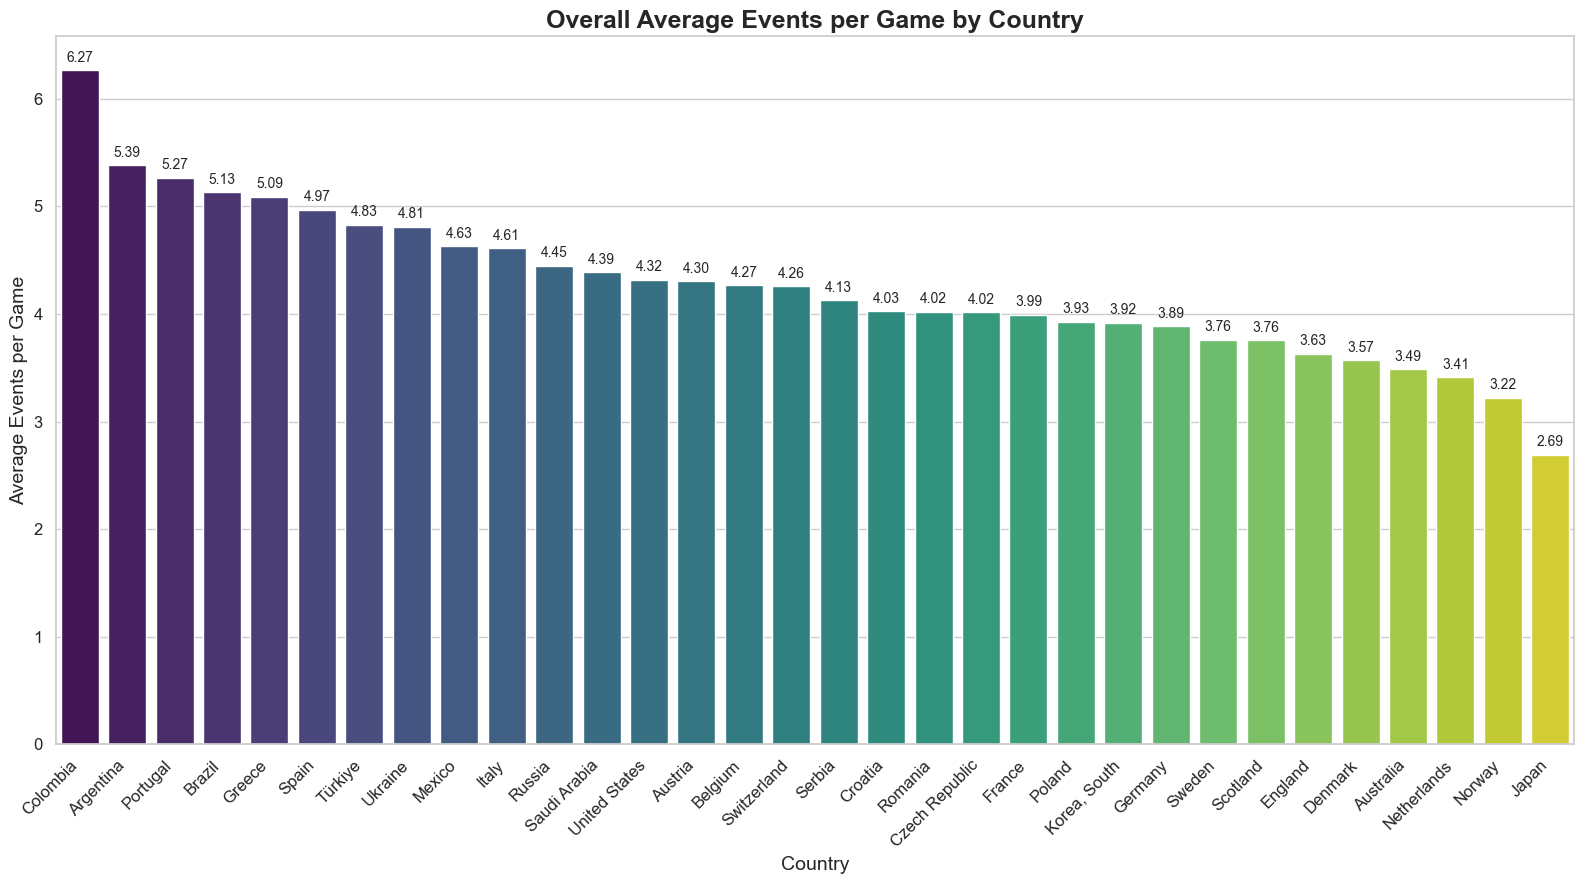

In [ ]:
def plot_average_events_per_country(file_path):
    """
    Calculates the overall average events per game for each country and
    creates a bar chart to visualize the results.

    Args:
        file_path (str): The path to the consolidated_game_events.csv file.
    """
    try:
        # Read the CSV file into a pandas DataFrame
        df = pd.read_csv(file_path)

        # --- Step 1: Calculate overall average events per game for each country ---

        # First, get the number of events for each unique game
        events_per_game = df.groupby('game_id').agg(
            num_of_events=('game_id', 'size'),
            country_name=('country_name', 'first')
        ).reset_index()

        # Now, group by country to calculate the total events and number of games
        country_summary = events_per_game.groupby('country_name').agg(
            total_events=('num_of_events', 'sum'),
            num_games=('game_id', 'nunique')
        ).reset_index()

        # Calculate the overall average events per game for each country
        country_summary['average_events_per_game'] = country_summary['total_events'] / country_summary['num_games']
        country_summary.to_csv('country_eventsPerGame.csv', index=False)
        
        # Display the resulting DataFrame
        print("--- Overall Average Events per Game by Country ---")
        print(country_summary[['country_name', 'average_events_per_game']].round(2))
        print("\n")


        # --- Step 2: Create a bar chart ---

        # Set a professional style for the plot
        sns.set_theme(style="whitegrid")

        # Create a figure and axes for the plot, making it larger for readability
        plt.figure(figsize=(16, 9))

        # Create the bar plot, ordering the countries by average events for better comparison
        barplot = sns.barplot(
            x='country_name',
            y='average_events_per_game',
            data=country_summary.sort_values('average_events_per_game', ascending=False),
            palette='viridis'  # Using a visually appealing color palette
        )

        # Add titles and labels for clarity
        plt.title('Overall Average Events per Game by Country', fontsize=18, fontweight='bold')
        plt.xlabel('Country', fontsize=14)
        plt.ylabel('Average Events per Game', fontsize=14)

        # Rotate the x-axis labels for better readability
        plt.xticks(rotation=45, ha='right', fontsize=12)
        plt.yticks(fontsize=12)

        # Add data labels on top of each bar for precise values
        for p in barplot.patches:
            barplot.annotate(format(p.get_height(), '.2f'),
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='center',
                           xytext=(0, 9),
                           textcoords='offset points',
                           fontsize=10)

        # Adjust layout to ensure all labels are visible
        plt.tight_layout()

        # Show the plot
        print("--- Generating Bar Chart ---")
        plt.show()


    except FileNotFoundError:
        print(f"Error: The file at {file_path} was not found.")
    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == '__main__':
    # Provide the full path to your CSV file
    file_path = r'your/path/to/consolidated_game_events.csv'
    plot_average_events_per_country(file_path)


Seeing Colombia, Argentina, Brazil and Mexico along with Portugal, Greece, Spain, Turkey and Italy near the top in average events per game show a geographical pattern, clustering events in South America and Southern Europ. 

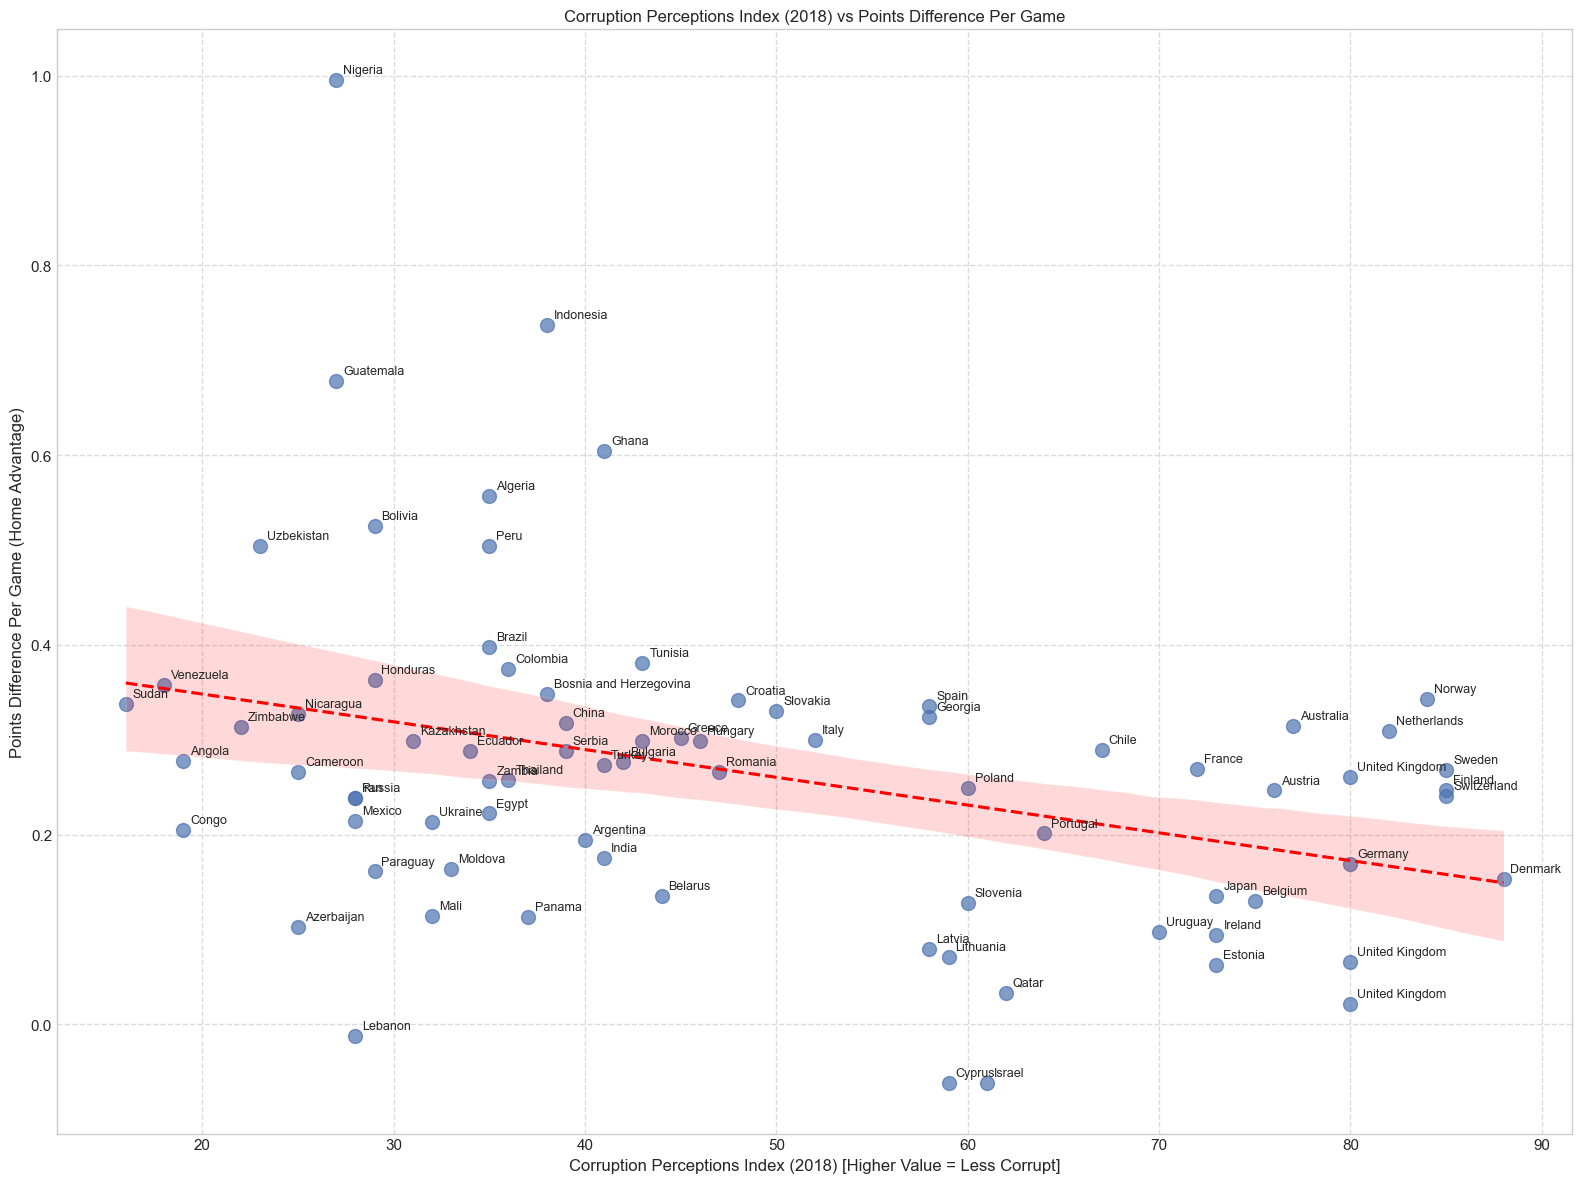

In [ ]:

# File paths
points_file = "your/path/to/points difference by country.csv"

cpi_file = "your/path/to/ti-corruption-perception-index.csv"

# Load the datasets
df_cpi = pd.read_csv(cpi_file)
df_points = pd.read_csv(points_file)

# Filter CPI data specifically for the year 2018
df_cpi_2018 = df_cpi[df_cpi['Year'] == 2018]

# Merge datasets based on aligned country names (Entity <-> Country_map)
df_merged = pd.merge(df_cpi_2018, df_points, left_on='Entity', right_on='Country_map', how='inner')

# Set up the scatter plot
#plt.figure(figsize=(12, 8))
# plt.scatter(df_merged['Corruption Perceptions Index'], df_merged['points_diff_per_game'], color='coral', edgecolor='black', alpha=0.8)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(16, 12))
sns.regplot(data=df_merged, x='Corruption Perceptions Index', y='points_diff_per_game',
            scatter_kws={'s': 100, 'alpha': 0.7},
            line_kws={'color': 'red', 'linestyle': '--'})

# Annotate each point with the country name for investigative tracking
for i, row in df_merged.iterrows():
    plt.annotate(row['Country_map'], (row['Corruption Perceptions Index'], row['points_diff_per_game']), xytext=(5, 5), textcoords='offset points', fontsize=9)



plt.title('Corruption Perceptions Index (2018) vs Points Difference Per Game')
plt.xlabel('Corruption Perceptions Index (2018) [Higher Value = Less Corrupt]')
plt.ylabel('Points Difference Per Game (Home Advantage)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Going deeper, we can also link home advantage to corruption, being a logical relation as if governments are corrupt, football federations can also be.

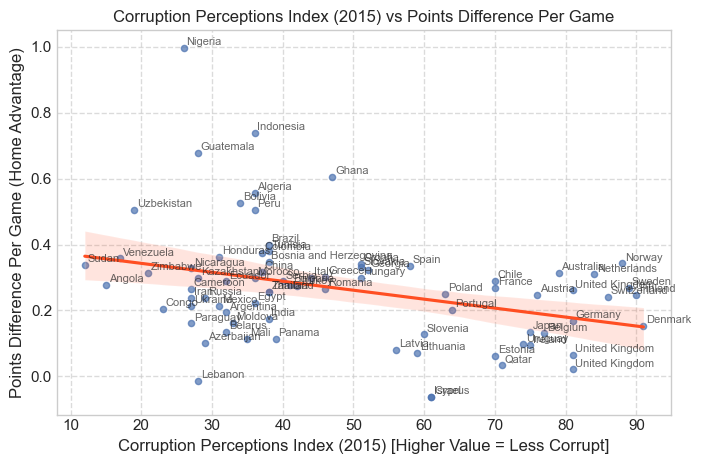

In [66]:


# Load the datasets
df_cpi = pd.read_csv(cpi_file)
df_points = pd.read_csv(points_file)

# Filter CPI data specifically for the year 2015
df_cpi_2015 = df_cpi[df_cpi['Year'] == 2015]

# Merge datasets based on aligned country names (Entity <-> Country_map)
df_merged = pd.merge(df_cpi_2015, df_points, left_on='Entity', right_on='Country_map', how='inner')

# Set up the scatter plot
#plt.figure(figsize=(12, 8))
# plt.scatter(df_merged['Corruption Perceptions Index'], df_merged['points_diff_per_game'], color='coral', edgecolor='black', alpha=0.8)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(7.2, 4.8))
sns.regplot(data=df_merged, x='Corruption Perceptions Index', y='points_diff_per_game',
            scatter_kws={'s': 20, 'alpha': 0.7},
            line_kws={'color': '#FF4E22'})

# Annotate each point with the country name for investigative tracking
for i, row in df_merged.iterrows():
    plt.annotate(row['Country_map'], (row['Corruption Perceptions Index'], row['points_diff_per_game']), xytext=(2, 2), textcoords='offset points', fontsize=8, alpha=0.7)



plt.title('Corruption Perceptions Index (2015) vs Points Difference Per Game')
plt.xlabel('Corruption Perceptions Index (2015) [Higher Value = Less Corrupt]')
plt.ylabel('Points Difference Per Game (Home Advantage)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [68]:


# Assuming you have a merged DataFrame named 'df_plot' that contains 
# 'cpi_2015', 'points_diff_per_game', and 'avg_gdp' (or just 'gdp')

fig = px.scatter(
    df_merged,
    x='Corruption Perceptions Index',
    y='points_diff_per_game',
    
    hover_name='Country', # Sets the bold title of the tooltip to the Country
    hover_data={
        'Country': False,         
        'Corruption Perceptions Index': True, 
        'points_diff_per_game': ':.3f'
    },
    
    color_discrete_sequence=['#6457CB'],
    opacity=0.8,  
    
    trendline='ols',                   # Fits a linear regression model through the data
    trendline_color_override='#FF4E22',
    
    title='Corruption Perception Index (2015) vs Home Advantage',
    labels={
        'Corruption Perceptions Index': 'Corruption Perception Index (2015)',
        'points_diff_per_game': 'Points diff. per game',
    }
)

corr_coef = df_merged['Corruption Perceptions Index'].corr(df_merged['points_diff_per_game'])
fig.add_annotation(
    x=0.98,
    y=0.95,
    xref='paper',
    yref='paper',
    text=f'Correlation Coefficient: {corr_coef:.2f}',
    showarrow=False,
    font=dict(family='Roboto', size=12, color='black'),
    borderwidth=1
)

# Apply axis styling (X solid with trims/ticks, Y hidden line/ticks)
fig.update_xaxes(
    showgrid=False,
    showline=True, 
    linecolor='black', 
    linewidth=1,
    ticks='outside', 
    title_font=dict(size=12),
    title_text='Corruption Perceptions Index (2015) [Higher Value = Less Corrupt]',
    #range=[-1, 1.5],
    anchor='free',
    #shift=10
)
fig.update_yaxes(
    showgrid=True,
    gridcolor='rgba(0, 0, 0, 0.1)',
    gridwidth=0.5,
    showline=False, 
    anchor='free',
    shift=-10,
    ticks='', 
    title_font=dict(size=12),
    title_text='Home vs Away Points Difference per Game',
)

# Apply exact figure size, fonts, and background colors
fig.update_layout(
    width=720,
    height=480,
    font=dict(family='Roboto'),
    plot_bgcolor='#f7f4ef',
    paper_bgcolor='#f7f4ef',
    
    title_x=0.5,        # Centers the title horizontally
    title_y=0.95,       # Moves the title slightly down from the top edge
    title_font_size=18,

    hoverlabel=dict(
        bgcolor="#dcd1c0",
        bordercolor="hsl(0, 0%, 30%)",
        font=dict(family='Roboto', size=10),
        showarrow=False  
    )
)

fig.write_html('Corruption vs Home Advantage.html')
fig.write_image('Corruption vs Home Advantage.png')
fig.show()


Final version of the plot for the webpage, as we stated earlier, corruption and home advantage is a logical link as referees or even players (like Barcelona B scandal in 2017, article is only available in Spanish as its not mainstream football https://www.record.com.mx/historia/barcelona-b-envuelto-en-escandalo-de-amano-2025102815583843564) can force a determinated result for money.

# Contributions

s260145 - Preliminar data analysis, home advantage vs socioeconomic factors analysis, interactive map analysis

s257662 - Corruption vs home advantage analysis, home advantage distribution analysis, html and css styling